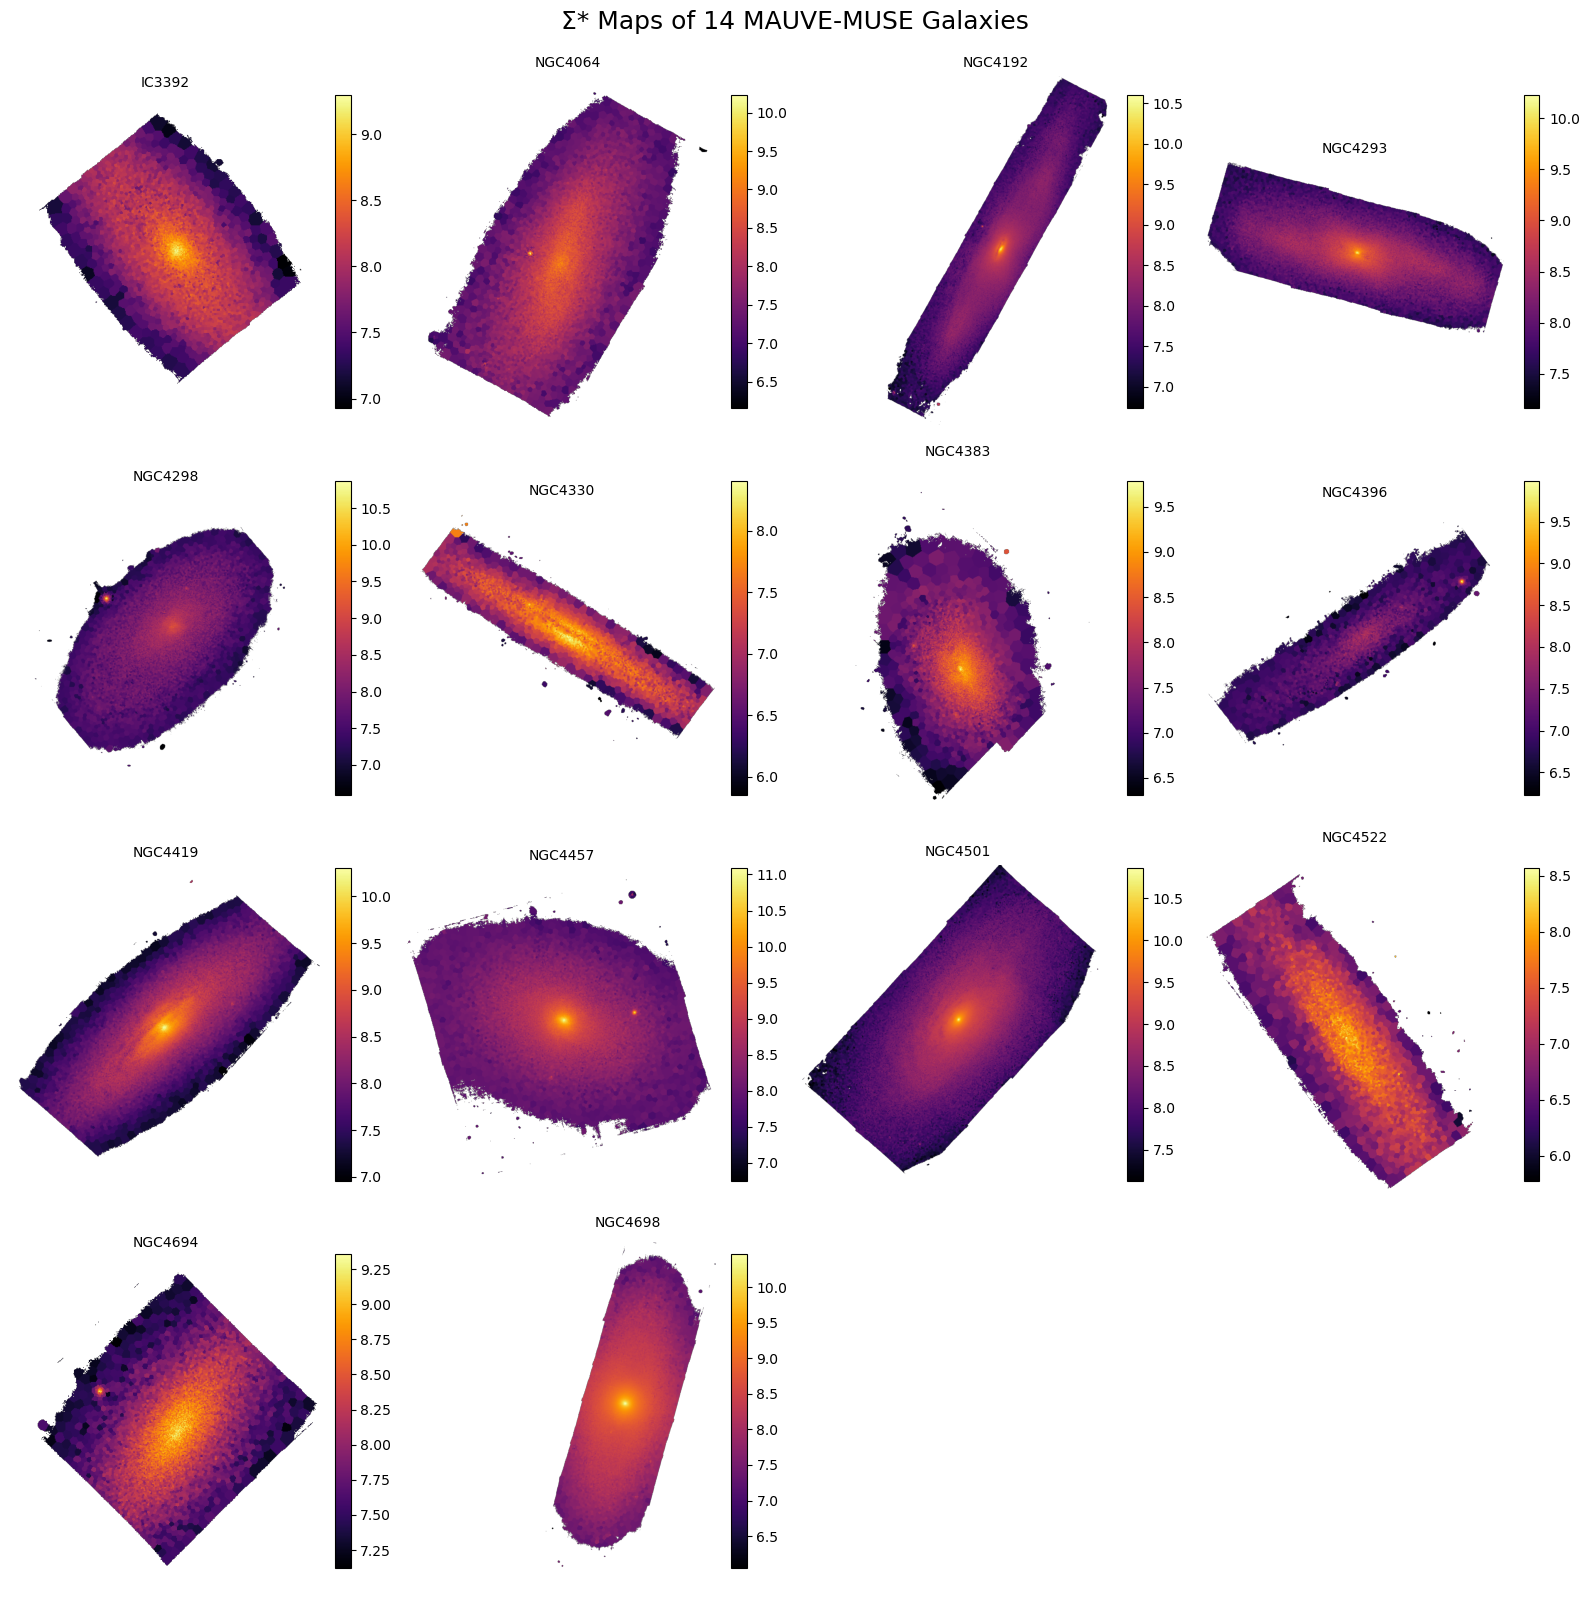

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from astropy.io import fits

# ------------------------------------------------------------------
# 0.  List galaxies
# ------------------------------------------------------------------
bin_maps = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bin_maps]        # auto-detect

# ------------------------------------------------------------------
# 1.  Helper: read Σ* map
# ------------------------------------------------------------------
def load_sigma_star(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    return sigM

# ------------------------------------------------------------------
# 2.  Create 4×4 grid showing Σ* maps
# ------------------------------------------------------------------
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, gal in enumerate(galaxies[:16]):  # Use up to 16 galaxies for 4×4 grid
    sigM = load_sigma_star(gal)
    
    im = axes[i].imshow(sigM, origin='lower', cmap='inferno')
    axes[i].set_title(rf'{gal}', fontsize=10)
    axes[i].axis('off')
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

# Hide any unused subplots
for i in range(len(galaxies), 16):
    axes[i].axis('off')

fig.suptitle(r'Σ* Maps of 14 MAUVE-MUSE Galaxies', fontsize=18, y=0.995)
fig.tight_layout()
fig.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_Sigma_Star_Maps_4x4.png', dpi=600)
fig.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_Sigma_Star_Maps_4x4.pdf')
plt.show()


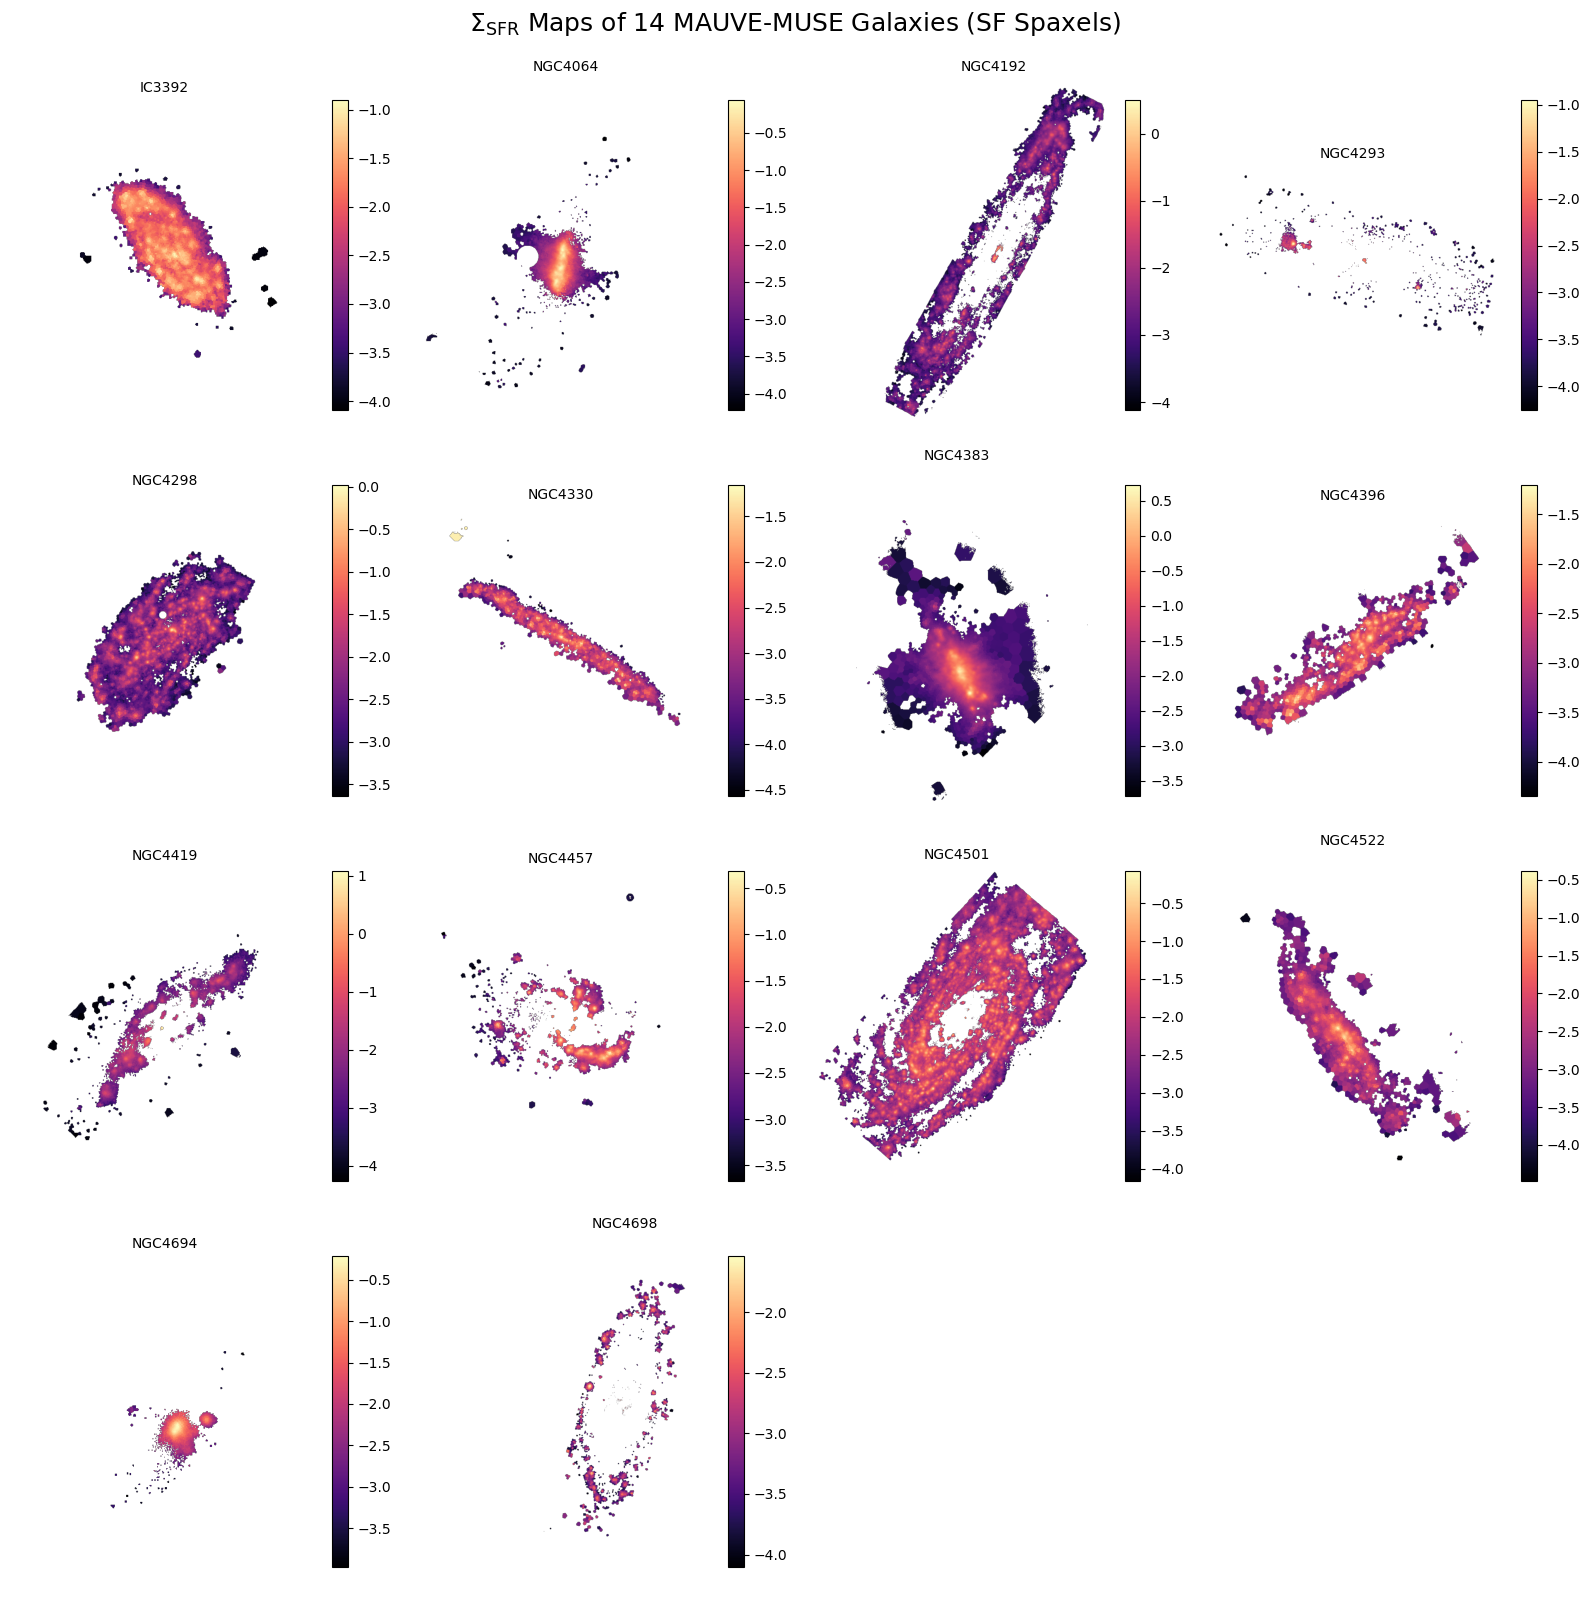

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from astropy.io import fits

# ------------------------------------------------------------------
# 0.  List galaxies
# ------------------------------------------------------------------
gas_bin_maps = sorted(Path('.').glob('*_gas_BIN_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in gas_bin_maps]        # auto-detect

# ------------------------------------------------------------------
# 1.  Helper: read Σ_SFR map
# ------------------------------------------------------------------
def load_sigma_sfr(gal):
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR = h['LOGSFR_SURFACE_DENSITY_SF'].data
    return sigSFR

# ------------------------------------------------------------------
# 2.  Create 4×4 grid showing Σ_SFR maps
# ------------------------------------------------------------------
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, gal in enumerate(galaxies[:16]):  # Use up to 16 galaxies for 4×4 grid
    sigSFR = load_sigma_sfr(gal)
    
    im = axes[i].imshow(sigSFR, origin='lower', cmap='magma')
    axes[i].set_title(rf'{gal}', fontsize=10)
    axes[i].axis('off')
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

# Hide any unused subplots
for i in range(len(galaxies), 16):
    axes[i].axis('off')

fig.suptitle(r'Σ$_{\mathrm{SFR}}$ Maps of 14 MAUVE-MUSE Galaxies (SF Spaxels)', fontsize=18, y=0.995)
fig.tight_layout()
fig.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_Sigma_SFR_Maps_SF_4x4.png', dpi=600)
fig.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_Sigma_SFR_Maps_SF_4x4.pdf', dpi=600)
plt.show()


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_24862/4191526397.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.98])


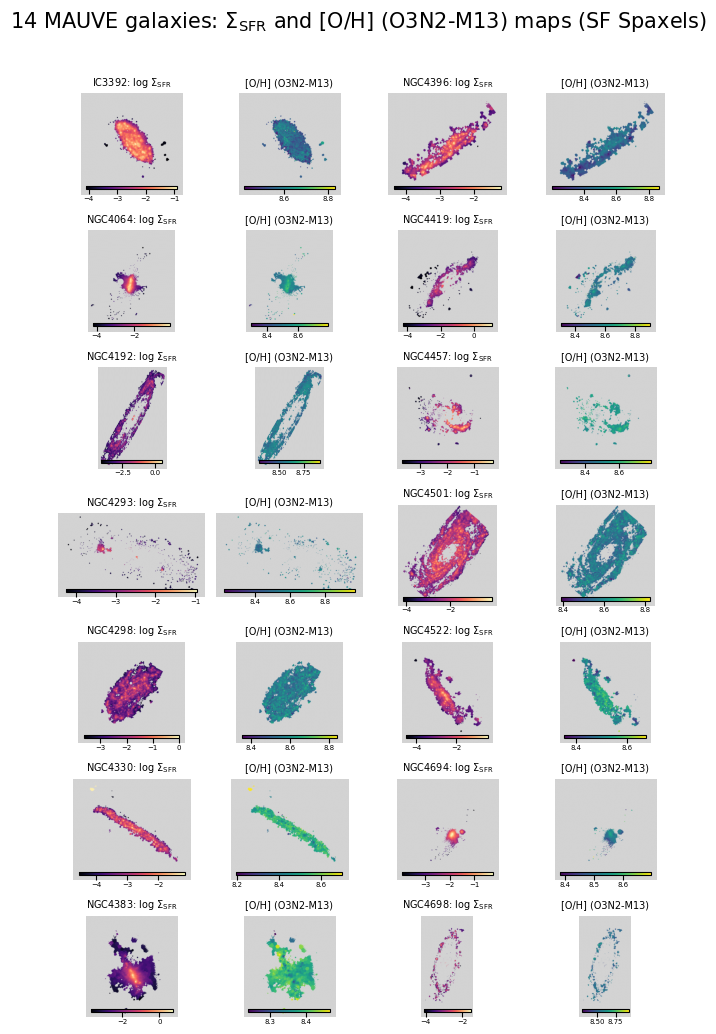

In [3]:
# --------------------------------------------------------------
# Maps: Σ_SFR map and [O/H] (O3N2-M13) map for each galaxy
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path
from astropy.io import fits

# 0 · discover galaxies
gas_bins = sorted(Path('.').glob('*_gas_BIN_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in gas_bins]          # 14 expected
ngal     = len(galaxies)
assert ngal <= 14, "This layout assumes ≤ 14 galaxies."

# Load maps helper (Σ_SFR, [O/H] O3N2-M13)
def load_maps(gal):
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_o3n2m13 = h['O_H_O3N2_M13_SF'].data
    return sigSFR_SF, oh_o3n2m13

# 1 · figure & GridSpec  (rows=7, cols=4 → two 2-column blocks per row)
fig = plt.figure(figsize=(8, 12))
gs  = GridSpec(
        nrows=7, ncols=4, figure=fig,
        width_ratios=[1, 1, 1, 1],            # Σ_SFR, [O/H] O3N2-M13 (repeated)
        wspace=0.08, hspace=0.35
)

for idx, gal in enumerate(galaxies):
    row  = idx % 7                      # 0–6
    blk  = idx // 7                     # 0 or 1   (left / right big column)
    col0 = blk * 2                      # 0 or 2   (start col of that block)

    sigSFR_SF, oh_o3n2m13 = load_maps(gal)

    # Σ_SFR map with NaN shown as light gray
    axS = fig.add_subplot(gs[row, col0])
    cmap_S = plt.cm.magma.copy(); cmap_S.set_bad('lightgray')
    imS = axS.imshow(sigSFR_SF, origin='lower', cmap=cmap_S)
    axS.set_title(rf'{gal}: $\log\,\Sigma_{{\mathrm{{SFR}}}}$', fontsize=7)
    axS.axis('off')
    cax1 = inset_axes(axS, width='90%', height='3%', loc='lower center', borderpad=0.4)
    fig.colorbar(imS, cax=cax1, orientation='horizontal')
    cax1.tick_params(labelsize=5, pad=1)

    # [O/H] O3N2-M13 map with NaN shown as light gray
    axOH = fig.add_subplot(gs[row, col0+1])
    cmap_OH = plt.cm.viridis.copy(); cmap_OH.set_bad('lightgray')
    imOH = axOH.imshow(oh_o3n2m13, origin='lower', cmap=cmap_OH)
    axOH.set_title(r'[O/H] (O3N2-M13)', fontsize=7)
    axOH.axis('off')
    cax2 = inset_axes(axOH, width='90%', height='3%', loc='lower center', borderpad=0.4)
    fig.colorbar(imOH, cax=cax2, orientation='horizontal')
    cax2.tick_params(labelsize=5, pad=1)

# 2 · global title
fig.suptitle(
    fr'{ngal} MAUVE galaxies: $\Sigma_{{\mathrm{{SFR}}}}$ and [O/H] (O3N2-M13) maps (SF Spaxels)',
    fontsize=15, y=0.95
)
fig.tight_layout(rect=[0, 0, 1, 0.98])

# Save figure in both PNG and PDF formats
fig.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_Sigma_SFR_OH_Maps_SF_4x4.png', dpi=600)
fig.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_Sigma_SFR_OH_Maps_SF_4x4.pdf')

plt.show()


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_24862/1748432141.py:272: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


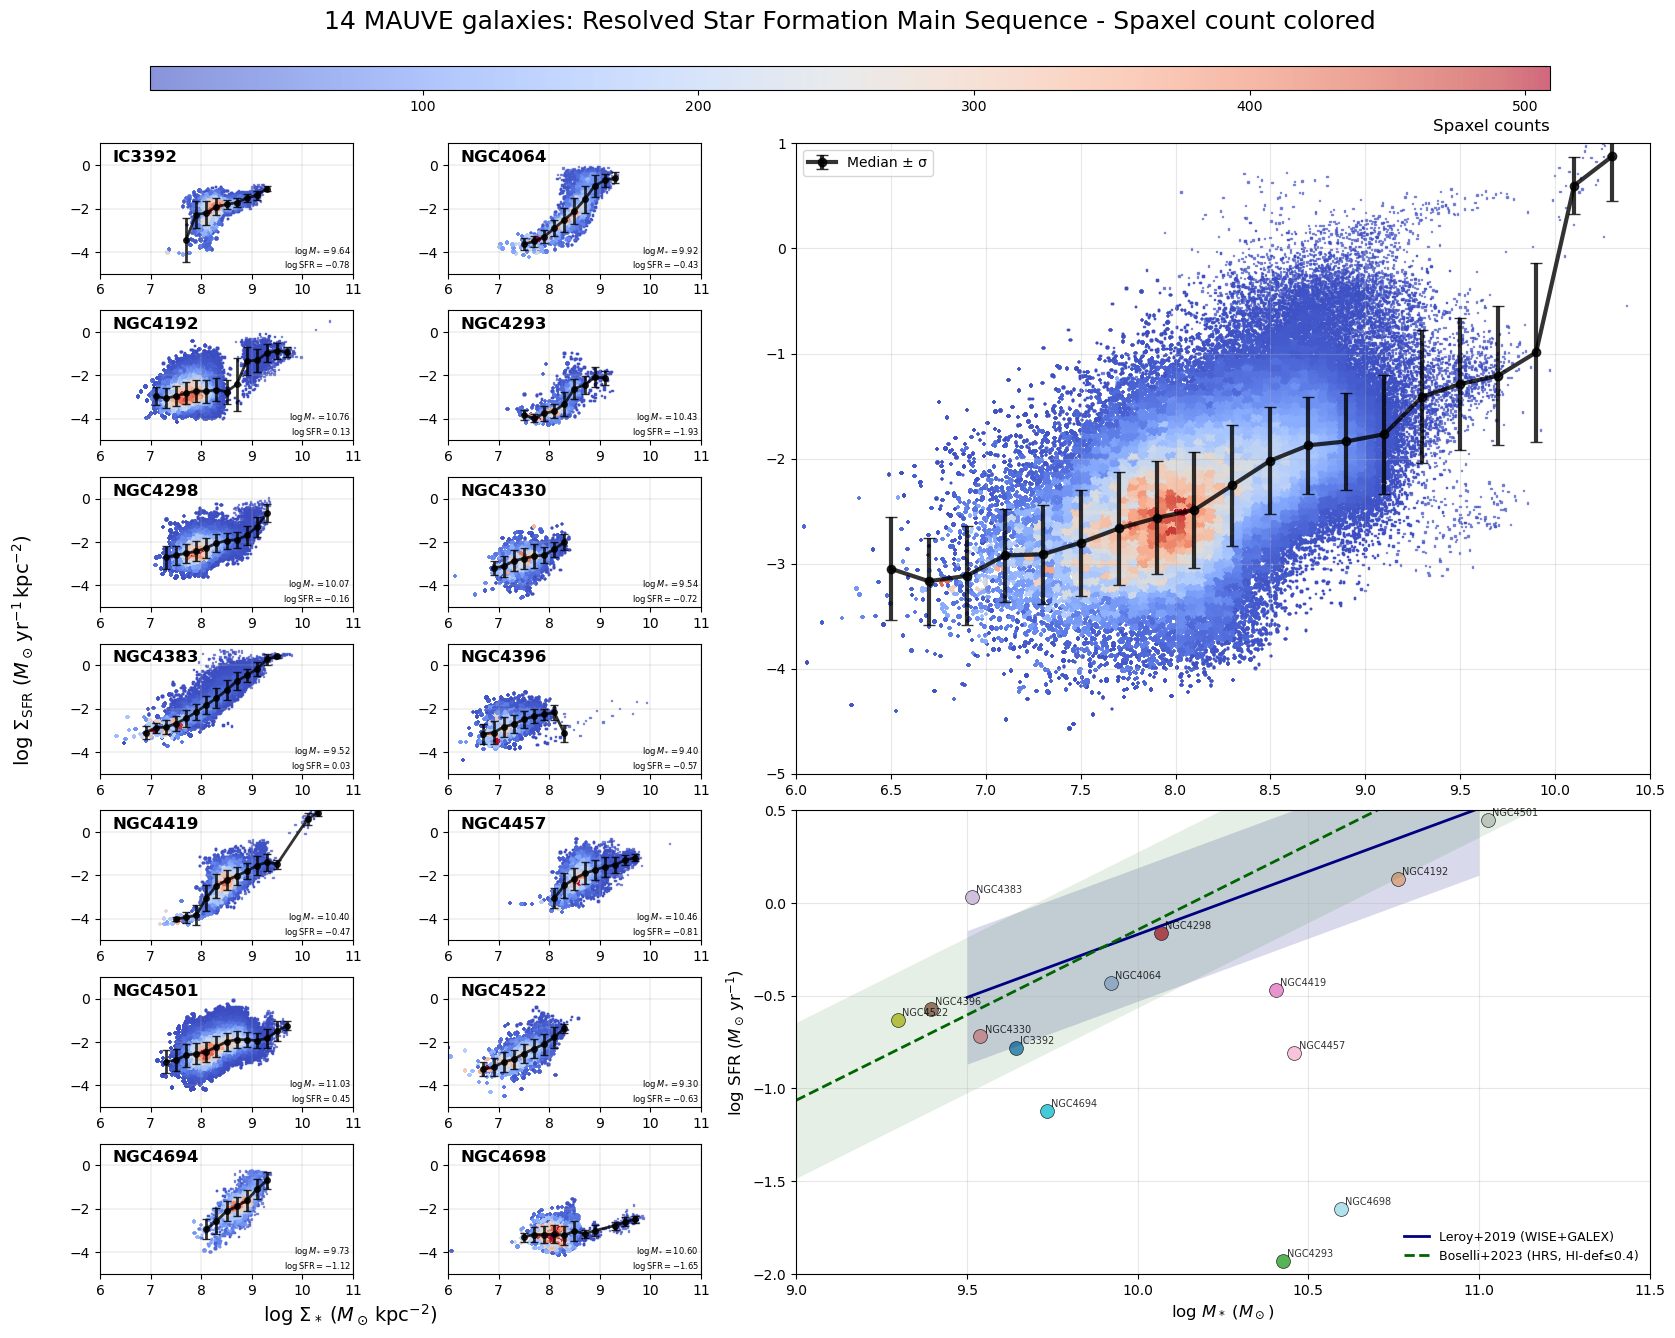

In [4]:
# ------------------------------------------------------------------
# COMPREHENSIVE LAYOUT: Individual galaxies + Combined plot + Statistics (rSFMS - [O/H] colored)
# 4-column layout: Cols 1-2 = Individual galaxies, Col 3 = Combined plot, Col 4 = Statistics
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from astropy.io import fits
import itertools
import re  # Add this import for regex

# 0 · discover galaxies & colour palette
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
ngal = len(galaxies)
assert ngal <= 14, "This layout assumes ≤ 14 galaxies."

def load_maps(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_o3n2m13 = h['O_H_O3N2_M13_SF'].data
    return sigM, sigSFR, oh_o3n2m13

# Extraction functions for log files
def extract_total_stellar_mass(galaxy_name):
    """Extract total stellar mass from mass log file. Returns log10(M☉) value or None if not found."""
    log_file = Path(f'mass_logs/{galaxy_name}.log')
    if not log_file.exists():
        return None
    
    try:
        with open(log_file, 'r') as f:
            content = f.read()
        pattern = r'Total stellar mass \(R\)\s*:\s*([\d.-]+)\s*log10\(M☉\)'
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading mass log for {galaxy_name}: {e}")
        return None

def extract_total_sfr(galaxy_name):
    """Extract total SFR from SFR log file. Returns log10(M☉/yr) value or None if not found."""
    log_file = Path(f'sfr_logs/{galaxy_name}.log')
    if not log_file.exists():
        return None
    
    try:
        with open(log_file, 'r') as f:
            content = f.read()
        pattern = r'Total Halpha SFR from SF region:.*?in log10 scale:\s*([\d.-]+)\s*log\(M☉/yr\)'
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading SFR log for {galaxy_name}: {e}")
        return None

def calculate_median_statistics(x, y, x_range=(6, 11), bin_width=0.2):
    """Calculate median and std in binned intervals"""
    x_bins = np.arange(x_range[0], x_range[1] + bin_width, bin_width)
    x_centers = (x_bins[:-1] + x_bins[1:]) / 2
    
    medians = []
    stds = []
    x_valid = []
    
    for i in range(len(x_bins) - 1):
        mask = (x >= x_bins[i]) & (x < x_bins[i + 1])
        if len(np.unique(x[mask])) >= 10:  # Need at least 10 distinct x values
            y_bin = y[mask]
            medians.append(np.median(y_bin))
            stds.append(np.std(y_bin))
            x_valid.append(x_centers[i])
    
    return np.array(x_valid), np.array(medians), np.array(stds)

# 1 · Create comprehensive figure with 4-column layout
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(nrows=8, ncols=4, figure=fig,
              width_ratios=[1, 1, 1.5, 1.5],  # Cols 3&4 slightly wider
              height_ratios=[0.5, 1, 1, 1, 1, 1, 1, 1],  # Row 0 for colorbar
              wspace=0.3, hspace=0.3)

plot_idx = 0
scatter_for_cbar = None
individual_stats = []

# COLUMNS 1-2: Individual galaxy plots
for idx, gal in enumerate(galaxies):
    sigM, sigSFR, oh_o3n2m13 = load_maps(gal)
    
    good = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_o3n2m13)
    
    if not np.any(good):
        print(f"Skipping {gal}: no valid data points")
        continue
    
    row = (plot_idx // 2) + 1  # Start from row 1 (row 0 for colorbar)
    col = plot_idx % 2
    plot_idx += 1

    axP = fig.add_subplot(gs[row, col])
    
    x_vals, y_vals, oh_vals = sigM[good], sigSFR[good], oh_o3n2m13[good]
    
    # Calculate median statistics
    x_median, y_median, y_std = calculate_median_statistics(x_vals, y_vals)
    individual_stats.append((gal, x_median, y_median, y_std, len(x_vals)))
    
    # Density-based scatter for individual galaxies
    H, xedges, yedges = np.histogram2d(x_vals, y_vals, bins=50, range=[[6, 11], [-5, 1]])
    x_idx = np.clip(np.digitize(x_vals, xedges) - 1, 0, H.shape[0] - 1)
    y_idx = np.clip(np.digitize(y_vals, yedges) - 1, 0, H.shape[1] - 1)
    density = H[x_idx, y_idx]
    
    # Scatter plot colored by density
    scatter = axP.scatter(x_vals, y_vals, c=density, s=1, alpha=0.6, marker=',', 
                         cmap='coolwarm')
    
    # Plot median with error bars
    if len(x_median) > 0:
        axP.errorbar(x_median, y_median, yerr=y_std, fmt='ko-', linewidth=2, 
                    markersize=4, capsize=3, alpha=0.8)
    
    if scatter_for_cbar is None:
        scatter_for_cbar = scatter
    
    # Add galaxy name in top left corner
    axP.text(0.05, 0.95, gal, transform=axP.transAxes, fontsize=12, fontweight='bold',
             va='top', ha='left', bbox=dict(boxstyle='round,pad=0.3', facecolor='none', alpha=0.8, edgecolor='none'))
    
    # Bottom right: total stellar mass and SFR from log files
    total_mass = extract_total_stellar_mass(gal)
    total_sfr = extract_total_sfr(gal)
    
    if total_mass is not None and total_sfr is not None:
        log_text = f'$\\log M_* = {total_mass:.2f}$\n$\\log \\mathrm{{SFR}} = {total_sfr:.2f}$'
        axP.text(0.99, 0.01, log_text,
                 transform=axP.transAxes, va='bottom', ha='right', fontsize=6,
                 bbox=dict(facecolor='none', alpha=0.8, edgecolor='none', pad=2))
    
    axP.set_xlim(6, 11)
    axP.set_ylim(-5, 1)
    axP.grid(True, lw=0.25)

# COLUMNS 3-4: Combined plot - Upper panel
ax_combined = fig.add_subplot(gs[1:5, 2:4])  # Spans rows 1-4, columns 2-3

# Collect all data for combined analysis
all_x, all_y, all_oh = [], [], []
galaxy_counts = {}

for gal in galaxies:
    sigM, sigSFR, oh_o3n2m13 = load_maps(gal)
    good = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_o3n2m13)
    
    if np.any(good):
        x_vals, y_vals, oh_vals = sigM[good], sigSFR[good], oh_o3n2m13[good]
        all_x.extend(x_vals)
        all_y.extend(y_vals)
        all_oh.extend(oh_vals)
        galaxy_counts[gal] = len(x_vals)
    else:
        galaxy_counts[gal] = 0

all_x, all_y, all_oh = np.array(all_x), np.array(all_y), np.array(all_oh)

# Calculate combined median statistics
x_median_combined, y_median_combined, y_std_combined = calculate_median_statistics(all_x, all_y)

# Density-based scatter for combined data
H, xedges, yedges = np.histogram2d(all_x, all_y, bins=100, range=[[6, 11], [-5, 1]])
x_idx = np.clip(np.digitize(all_x, xedges) - 1, 0, H.shape[0] - 1)
y_idx = np.clip(np.digitize(all_y, yedges) - 1, 0, H.shape[1] - 1)
density = H[x_idx, y_idx]

# Scatter plot colored by density for combined data
scatter_combined = ax_combined.scatter(all_x, all_y, c=density, s=1, alpha=0.6, marker=',', 
                                      cmap='coolwarm')

# Plot combined median with error bars
ax_combined.errorbar(x_median_combined, y_median_combined, yerr=y_std_combined, 
                    fmt='ko-', linewidth=3, markersize=6, capsize=4, alpha=0.8, label='Median ± σ')
ax_combined.legend(fontsize=10, loc='upper left')

ax_combined.set_xlim(6.0, 10.5)
ax_combined.set_ylim(-5, 1)
ax_combined.grid(True, alpha=0.3)

# COLUMNS 3-4: Global SFMS plot - Lower panel
ax_sfms = fig.add_subplot(gs[5:8, 2:4])  # Spans rows 5-7, columns 2-3

# SFMS relation functions
def sfms_leroy2019(logM, scatter=0.36, valid=(9.5, 11.0)):
    """Leroy+2019 eq.19 converted to log SFR: logSFR = 0.68*logM - 6.97."""
    y = 0.68 * np.asarray(logM) - 6.97
    y = np.where((logM < valid[0]) | (logM > valid[1]), np.nan, y)
    return y

def sfms_boselli2023(logM, slope=0.92, intercept=-1.57, x_pivot=8.451, scatter=0.42):
    """Boselli+2023 (HRS, HI-def ≤ 0.4): fit with pivot x_pivot."""
    logM = np.asarray(logM)
    y = slope * (logM - x_pivot) + intercept
    return y

# Extract total masses and SFRs for global SFMS
log_masses = []
log_sfrs = []
sfms_galaxy_names = []

for gal in galaxies:
    mass = extract_total_stellar_mass(gal)
    sfr = extract_total_sfr(gal)
    
    if mass is not None and sfr is not None:
        log_masses.append(mass)
        log_sfrs.append(sfr)
        sfms_galaxy_names.append(gal)

log_masses = np.array(log_masses)
log_sfrs = np.array(log_sfrs)

# Color-code each galaxy
colors_total = plt.cm.tab20(np.linspace(0, 1, len(sfms_galaxy_names)))

# Plot points and add galaxy names
for i, (mass, sfr, gal) in enumerate(zip(log_masses, log_sfrs, sfms_galaxy_names)):
    ax_sfms.scatter(mass, sfr, s=100, c=[colors_total[i]], alpha=0.8, 
                   edgecolors='black', linewidth=0.5)
    ax_sfms.annotate(gal, (mass, sfr), xytext=(3, 3), textcoords='offset points', 
                    fontsize=7, alpha=0.8)

# Add SFMS relations
x_line = np.linspace(9, 11.5, 400)

# Leroy+2019 line + ±0.36 dex band
y_l19 = sfms_leroy2019(x_line)
ax_sfms.plot(x_line, y_l19, lw=2, ls='-', label='Leroy+2019 (WISE+GALEX)', color='navy')
ax_sfms.fill_between(x_line, y_l19 - 0.36, y_l19 + 0.36, alpha=0.15, linewidth=0, color='navy')

# Boselli+2023 line + intrinsic-scatter band
y_b23 = sfms_boselli2023(x_line)
ax_sfms.plot(x_line, y_b23, lw=2, ls='--', label='Boselli+2023 (HRS, HI-def≤0.4)', color='darkgreen')
ax_sfms.fill_between(x_line, y_b23 - 0.42, y_b23 + 0.42, alpha=0.10, linewidth=0, color='darkgreen')

# Formatting
ax_sfms.set_xlabel(r'$\log\,M_* \; (M_\odot)$', fontsize=12)
ax_sfms.set_ylabel(r'$\log\,\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1})$', fontsize=12)
ax_sfms.grid(True, alpha=0.3)
ax_sfms.set_xlim(9, 11.5)
ax_sfms.set_ylim(-2, 0.5)
ax_sfms.legend(frameon=False, fontsize=9, loc='lower right')

# Add horizontal colorbar at the top
if scatter_for_cbar is not None:
    cbar_ax = fig.add_axes([0.15, 0.85, 0.7, 0.015])
    cbar = plt.colorbar(scatter_for_cbar, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(r'Spaxel counts', fontsize=12, loc='right')

# Global title and labels
fig.suptitle(fr'{ngal} MAUVE galaxies: Resolved Star Formation Main Sequence - Spaxel count colored', 
             fontsize=18, y=0.90)

# Shared axis labels
fig.text(0.25, 0.08, r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', 
         ha='center', fontsize=14)
fig.text(0.08, 0.5, r'$\log\,\Sigma_{\mathrm{SFR}} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', 
         va='center', rotation='vertical', fontsize=14)

fig.tight_layout(rect=[0, 0, 1, 1])
fig.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rSFMS_SF.png', dpi=600)
fig.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rSFMS_SF.pdf')
plt.show()


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_24862/3171219409.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_24862/3171219409.py:500: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle and legend
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_24862/3171219409.py:500: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle and legend


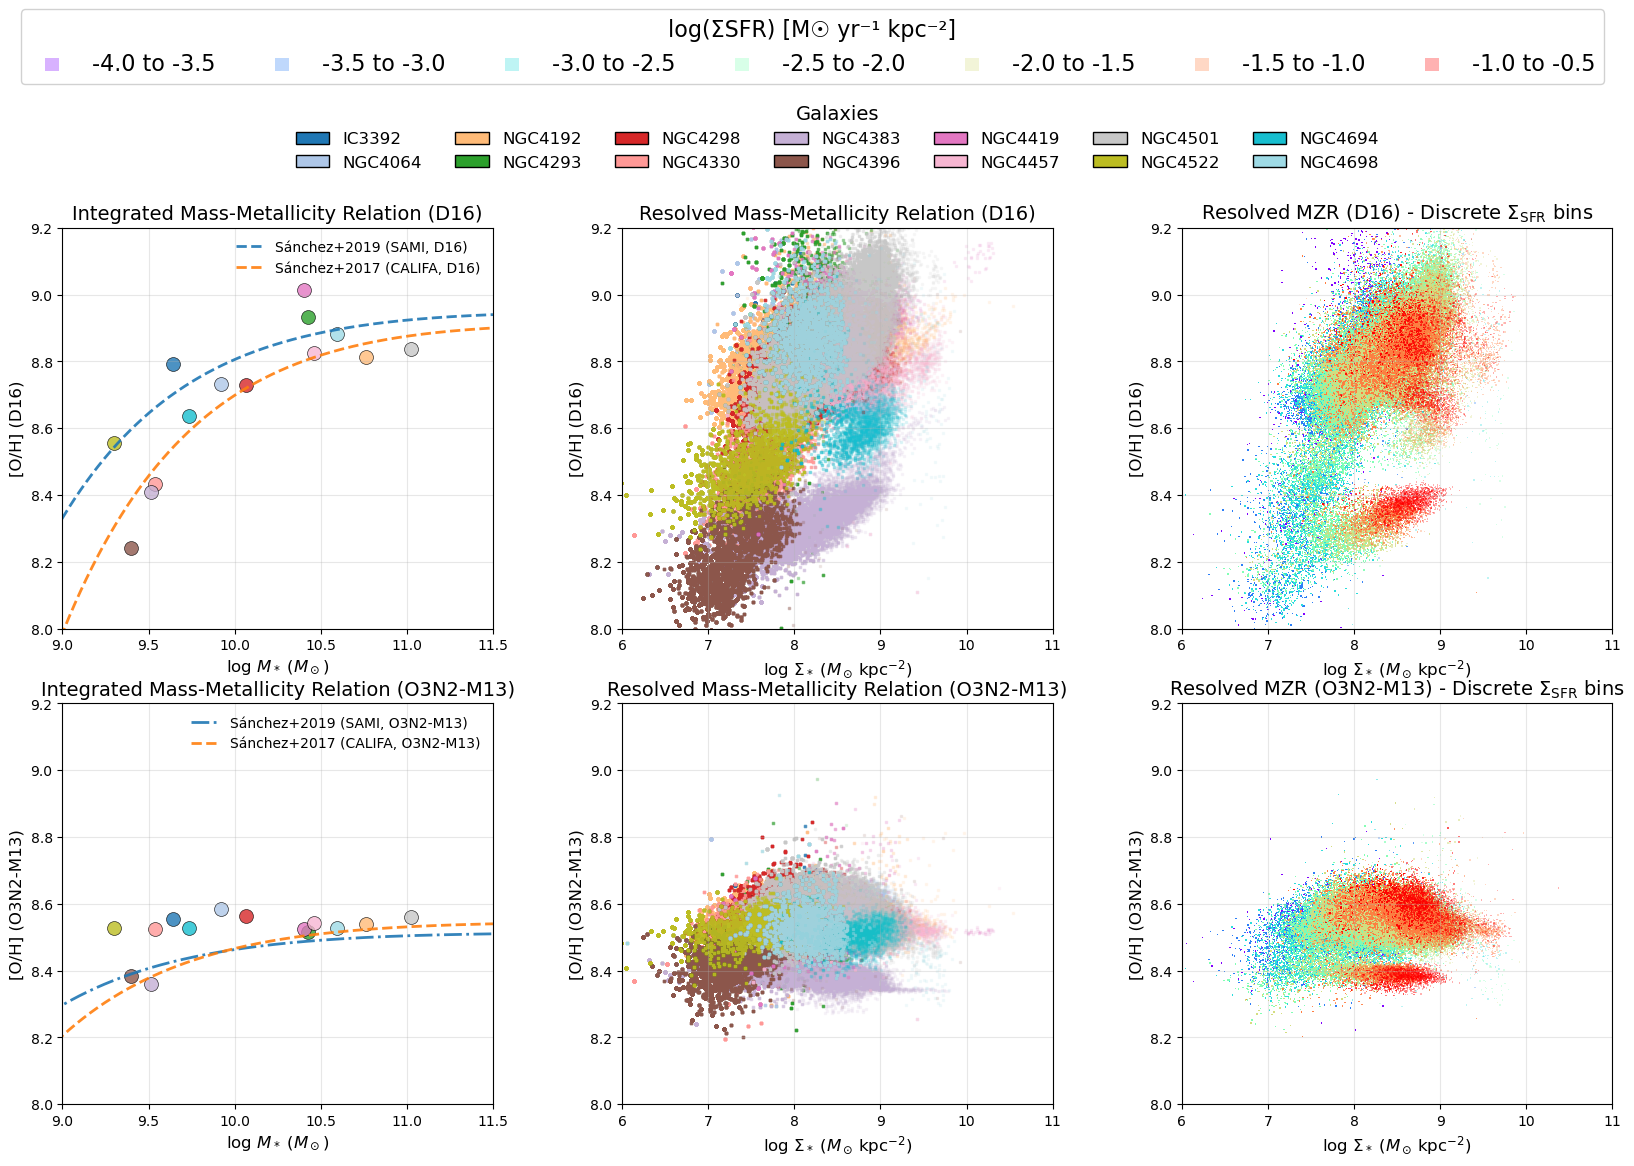

D16 - Subplot 1: Plotted 14 galaxies with valid total mass and D16 metallicity data
D16 - Subplot 2: Plotted spatially-resolved D16 MZR data for 14 galaxies
D16 - Subplot 3: Plotted 1246932 spaxels in 7 discrete Σ_SFR bins
O3N2-M13 - Plotted 14 galaxies
O3N2-M13 - Subplot 3: Plotted 1252169 spaxels in 7 discrete Σ_SFR bins


In [5]:
# ------------------------------------------------------------------
# Combined Plot: Integrated MZR (D16) + Resolved MZR (D16)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import itertools
from scipy.stats import linregress
from astropy.io import fits

def mzr_tremonti2004(logM):
    logM = np.asarray(logM, dtype=float)
    oh12 = -1.492 + 1.847*logM - 0.08026*(logM**2)
    oh12[(logM < 8.5) | (logM > 11.5)] = np.nan
    return oh12

def mzr_zahid2014(logM, Z0=8.710, logM0=8.76, gamma=0.66):
    logM = np.asarray(logM, dtype=float)
    term = 1.0 + 10.0**(-gamma * (logM - logM0))
    return Z0 - np.log10(term)

def mzr_curti2020(logM, Z0=8.793, logM0=10.02, gamma=0.28, beta=1.2):
    logM = np.asarray(logM, dtype=float)
    term = 1.0 + 10.0**(-beta * (logM - logM0))
    return Z0 - (gamma / beta) * np.log10(term)

def mzr_sanchez2019(logM, a, b, c=3.5):
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)

S19_PARAMS = {
    "O3N2-M13": dict(a=8.51, b=0.007),
    "PP04"    : dict(a=8.73, b=0.010),
    "N2-M13"  : dict(a=8.50, b=0.008),
    "T04"     : dict(a=8.84, b=0.007),
    "D16"     : dict(a=8.94, b=0.020),  # table's DOP16 = D16
}

S19_STYLES = {
    "O3N2-M13": "-.",
    "PP04"    : (0, (5, 1.5)),
    "N2-M13"  : ":",
    "T04"     : (0, (3, 1.2, 1, 1.2)),
    "D16"     : "--",
}

# --- NEW: Sánchez+2017 (same functional form as 2019) ---
def mzr_sanchez2017(logM, a, b, c=3.5):
    logM = np.asarray(logM, dtype=float)
    x = logM - 8.0
    t = x - c
    return a + b * t * np.exp(-t)

# --- NEW: Sánchez+2017 (CALIFA) parameters for 5 requested calibrations ---
# CALIFA table labels DOP16; we keep the external key as "D16" for consistency.
S17_PARAMS = {
    "O3N2-M13": dict(a=8.54, b=0.011),
    "PP04"    : dict(a=8.78, b=0.017),
    "N2-M13"  : dict(a=8.54, b=0.013),
    "T04"     : dict(a=8.94, b=0.014),
    "D16"     : dict(a=8.90, b=0.030),  # CALIFA "DOP16"
}

def plot_previous_MZR(ax=None,
                      mass_range=(8.5, 11.5),
                      zahid_params=dict(Z0=8.710, logM0=8.76, gamma=0.66),
                      curti_params=dict(Z0=8.793, logM0=10.02, gamma=0.28, beta=1.2),
                      include=('T04','Z14','C20'),
                      sanchez_calibs=("O3N2-M13", "PP04", "N2-M13", "T04", "D16"),
                      # NEW: off by default to preserve behavior
                      sanchez2017_calibs=(),
                      show_legend=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    logM = np.linspace(mass_range[0], mass_range[1], 800)

    # === Literature curves ===
    if 'T04' in include:
        ax.plot(logM, mzr_tremonti2004(logM), lw=2,
                label='Tremonti+2004 (SDSS, R23–T04)')
    if 'Z14' in include:
        z = mzr_zahid2014(logM, **zahid_params)
        ax.plot(logM, z, lw=2, ls='--',
                label='Zahid+2014 (SDSS, N2–PP04)')
    if 'C20' in include:
        c = mzr_curti2020(logM, **curti_params)
        ax.plot(logM, c, lw=2, ls=':',
                label='Curti+2020 (SDSS, Combined–C20)')

    # Sánchez+2019 (SAMI)
    for calib in sanchez_calibs:
        if calib not in S19_PARAMS:
            continue
        pars = S19_PARAMS[calib]
        y = mzr_sanchez2019(logM, **pars)
        ls = S19_STYLES.get(calib, "-.")
        ax.plot(logM, y, lw=2, ls=ls, alpha=0.9,
                label=f"Sánchez+2019 (SAMI, {calib})")

    # --- NEW: Sánchez+2017 (CALIFA) optional overlay ---
    for calib in sanchez2017_calibs:
        if calib not in S17_PARAMS:
            continue
        pars = S17_PARAMS[calib]
        y = mzr_sanchez2017(logM, **pars)
        ax.plot(logM, y, lw=2, ls='--', alpha=0.9,
                label=f"Sánchez+2017 (CALIFA, {calib})")

    ax.set_xlim(mass_range)
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$')
    ax.set_ylabel(r'$12+\log_{10}(\mathrm{O/H})$')
    ax.set_xlim(9, 11.5)
    ax.set_ylim(8.0, 9.2)
    ax.grid(True, alpha=0.3)
    if show_legend:
        ax.legend(frameon=False, ncol=1)
    plt.tight_layout()
    return ax

# Create figure with 2 rows x 3 columns + colorbar + legend rows
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(20, 14))
gs = GridSpec(nrows=4, ncols=3, figure=fig, 
              height_ratios=[0.05, 0.08, 1, 1],  # Row 0: SFR legend, Row 1: galaxy legend, Rows 2-3: data
              hspace=0.35, wspace=0.3)

# ------------------------------------------------------------------
# ROW 2 (D16): Total Stellar Mass vs Total D16 Metallicity from log files
# ------------------------------------------------------------------

ax1 = fig.add_subplot(gs[2, 0])  # Row 2, Col 0

# Extraction functions for log files
def extract_total_stellar_mass(galaxy_name):
    """Extract total stellar mass from mass log file. Returns log10(M☉) value or None if not found."""
    log_file = Path(f'mass_logs/{galaxy_name}.log')
    if not log_file.exists():
        return None
    
    try:
        with open(log_file, 'r') as f:
            content = f.read()
        pattern = r'Total stellar mass \(R\)\s*:\s*([\d.-]+)\s*log10\(M☉\)'
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading mass log for {galaxy_name}: {e}")
        return None

def extract_total_d16_metallicity(galaxy_name):
    """Extract total D16 metallicity from log file. Returns [O/H] D16 value or None if not found."""
    log_file = Path(f'sfr_logs/{galaxy_name}.log')
    if not log_file.exists():
        return None
    
    try:
        with open(log_file, 'r') as f:
            content = f.read()
        pattern = r'\[O/H\] D16 SF: Total metallicity in SF region:\s*([\d.-]+)'
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading D16 metallicity log for {galaxy_name}: {e}")
        return None

# Discover galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Create galaxy color mapping (consistent for both subplots)
galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))
galaxy_color_dict = dict(zip(galaxies, galaxy_colors))

# Extract total masses and D16 metallicities
log_masses = []
d16_metallicities = []
galaxy_names = []

for gal in galaxies:
    mass = extract_total_stellar_mass(gal)
    metallicity = extract_total_d16_metallicity(gal)
    
    if mass is not None and metallicity is not None:
        log_masses.append(mass)
        d16_metallicities.append(metallicity)
        galaxy_names.append(gal)

# Convert to numpy arrays
log_masses = np.array(log_masses)
d16_metallicities = np.array(d16_metallicities)

# Plot reference MZR relations from literature (D16-relevant only)
plot_previous_MZR(ax=ax1, show_legend=True, include=(), sanchez_calibs=("D16",), sanchez2017_calibs=("D16",))

# Plot subplot 1 using consistent colors (no labels for legend)
for i, (mass, metallicity, gal) in enumerate(zip(log_masses, d16_metallicities, galaxy_names)):
    ax1.scatter(mass, metallicity, s=100, c=[galaxy_color_dict[gal]], alpha=0.8, 
               edgecolors='black', linewidth=0.5)

# Add labels and formatting for subplot 1
ax1.set_xlabel(r'$\log\,M_* \; (M_\odot)$', fontsize=12)
ax1.set_ylabel(r'[O/H] (D16)', fontsize=12)
ax1.set_title('Integrated Mass-Metallicity Relation (D16)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(9, 11.5)
ax1.set_ylim(8.0, 9.2)

# ------------------------------------------------------------------
# ROW 2 (D16): Spatially-resolved Σ* vs [O/H] D16
# ------------------------------------------------------------------

ax2 = fig.add_subplot(gs[2, 1])  # Row 2, Col 1

# Collect all data points for global fit
all_x = []
all_y = []

for gal in galaxies:
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    
    if not bin_file.exists() or not gas_file.exists():
        continue

    # Read FITS extensions
    try:
        with fits.open(bin_file) as hdul:
            logSigmaM = hdul['LOGMASS_SURFACE_DENSITY'].data  # Σ*
        with fits.open(gas_file) as hdul:
            oh_d16 = hdul['O_H_D16_SF'].data  # [O/H] D16

        # Mask bad pixels
        good = np.isfinite(logSigmaM) & np.isfinite(oh_d16)

        # Scatter plot using consistent galaxy colors
        ax2.scatter(
            logSigmaM[good],
            oh_d16[good],
            s=1, 
            marker=',', 
            alpha=0.1,
            color=galaxy_color_dict[gal],
            label=gal
        )
        
        # Collect points for global fit
        all_x.extend(logSigmaM[good])
        all_y.extend(oh_d16[good])
        
    except Exception as e:
        print(f"Error processing {gal}: {e}")
        continue

# Final cosmetics for subplot 2
ax2.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax2.set_ylabel(r'[O/H] (D16)', fontsize=12)
ax2.set_title(r'Resolved Mass-Metallicity Relation (D16)', fontsize=14)
ax2.set_xlim(6, 11)
ax2.set_ylim(8.0, 9.2)
ax2.grid(True, alpha=0.3)

# ------------------------------------------------------------------
# ROW 2 (D16): Spatially-resolved Σ* vs [O/H] D16, colored by discrete Σ_SFR bins
# ------------------------------------------------------------------

ax3 = fig.add_subplot(gs[2, 2])  # Row 2, Col 2

# Define 8 discrete Σ_SFR bins: -4 to 0.0 with 0.5 bin width (same as cell 6)
sfr_bin_edges = np.arange(-4, 0.0, 0.5)
n_bins = len(sfr_bin_edges) - 1
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# Collect all data points for subplot 3
all_x_sfr = []
all_y_sfr = []
all_sfr = []

for gal in galaxies:
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    
    if not bin_file.exists() or not gas_file.exists():
        continue

    # Read FITS extensions
    try:
        with fits.open(bin_file) as hdul:
            logSigmaM = hdul['LOGMASS_SURFACE_DENSITY'].data  # Σ*
        with fits.open(gas_file) as hdul:
            oh_d16 = hdul['O_H_D16_SF'].data  # [O/H] D16
            sigSFR = hdul['LOGSFR_SURFACE_DENSITY_SF'].data  # Σ_SFR

        # Mask bad pixels
        good = np.isfinite(logSigmaM) & np.isfinite(oh_d16) & np.isfinite(sigSFR)

        # Collect points
        all_x_sfr.extend(logSigmaM[good])
        all_y_sfr.extend(oh_d16[good])
        all_sfr.extend(sigSFR[good])
        
    except Exception as e:
        print(f"Error processing {gal} for subplot 3: {e}")
        continue

# Convert to arrays
all_x_sfr = np.array(all_x_sfr)
all_y_sfr = np.array(all_y_sfr)
all_sfr = np.array(all_sfr)

# Plot each SFR bin with discrete colors
legend_handles = []
legend_labels = []

for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
    in_bin = (all_sfr >= bin_start) & (all_sfr < bin_end)
    if np.sum(in_bin) > 0:
        scatter_d16 = ax3.scatter(all_x_sfr[in_bin], all_y_sfr[in_bin], 
                                  c=[colors_sfr[i]], s=1, marker=',', alpha=0.3, 
                                  edgecolors='none', rasterized=True)
        legend_handles.append(scatter_d16)
        legend_labels.append(f'{bin_start:.1f} to {bin_end:.1f}')

# Final cosmetics for subplot 3
ax3.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax3.set_ylabel(r'[O/H] (D16)', fontsize=12)
ax3.set_title(r'Resolved MZR (D16) - Discrete $\Sigma_{\mathrm{SFR}}$ bins', fontsize=14)
ax3.set_xlim(6, 11)
ax3.set_ylim(8.0, 9.2)
ax3.grid(True, alpha=0.3)

# ------------------------------------------------------------------
# ROW 3 (O3N2-M13): Integrated + Resolved MZR
# ------------------------------------------------------------------

def extract_total_o3n2m13_metallicity(galaxy_name):
    """Extract total O3N2-M13 metallicity from log file."""
    log_file = Path(f'sfr_logs/{galaxy_name}.log')
    if not log_file.exists():
        return None
    
    try:
        with open(log_file, 'r') as f:
            content = f.read()
        pattern = r'\[O/H\] O3N2-M13 SF: Total metallicity in SF region:\s*([\d.-]+)'
        match = re.search(pattern, content)
        return float(match.group(1)) if match else None
    except Exception as e:
        print(f"Error reading O3N2-M13 metallicity log for {galaxy_name}: {e}")
        return None

# Subplot 1: Integrated MZR (O3N2-M13)
ax7 = fig.add_subplot(gs[3, 0])

o3n2m13_metallicities = []
o3n2m13_galaxy_names = []

for gal in galaxies:
    mass = extract_total_stellar_mass(gal)
    metallicity = extract_total_o3n2m13_metallicity(gal)
    
    if mass is not None and metallicity is not None:
        o3n2m13_metallicities.append(metallicity)
        o3n2m13_galaxy_names.append(gal)

o3n2m13_metallicities = np.array(o3n2m13_metallicities)

# Plot reference MZR
plot_previous_MZR(ax=ax7, show_legend=True, include=(), sanchez_calibs=("O3N2-M13",), sanchez2017_calibs=("O3N2-M13",))

for i, (mass, metallicity, gal) in enumerate(zip(log_masses, o3n2m13_metallicities, o3n2m13_galaxy_names)):
    ax7.scatter(mass, metallicity, s=100, c=[galaxy_color_dict[gal]], alpha=0.8, 
               edgecolors='black', linewidth=0.5)

ax7.set_xlabel(r'$\log\,M_* \; (M_\odot)$', fontsize=12)
ax7.set_ylabel(r'[O/H] (O3N2-M13)', fontsize=12)
ax7.set_title('Integrated Mass-Metallicity Relation (O3N2-M13)', fontsize=14)
ax7.grid(True, alpha=0.3)
ax7.set_xlim(9, 11.5)
ax7.set_ylim(8.0, 9.2)

# Subplot 2: Resolved MZR (O3N2-M13)
ax8 = fig.add_subplot(gs[3, 1])

for gal in galaxies:
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    
    if not bin_file.exists() or not gas_file.exists():
        continue

    try:
        with fits.open(bin_file) as hdul:
            logSigmaM = hdul['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(gas_file) as hdul:
            oh_o3n2m13 = hdul['O_H_O3N2_M13_SF'].data

        good = np.isfinite(logSigmaM) & np.isfinite(oh_o3n2m13)

        ax8.scatter(
            logSigmaM[good],
            oh_o3n2m13[good],
            s=1, 
            marker=',', 
            alpha=0.1,
            color=galaxy_color_dict[gal],
            label=gal
        )
        
    except Exception as e:
        print(f"Error processing {gal} for O3N2-M13: {e}")
        continue

ax8.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax8.set_ylabel(r'[O/H] (O3N2-M13)', fontsize=12)
ax8.set_title(r'Resolved Mass-Metallicity Relation (O3N2-M13)', fontsize=14)
ax8.set_xlim(6, 11)
ax8.set_ylim(8.0, 9.2)
ax8.grid(True, alpha=0.3)

# Subplot 3: Resolved MZR (O3N2-M13) colored by discrete Σ_SFR bins
ax9 = fig.add_subplot(gs[3, 2])

all_x_o3n2m13 = []
all_y_o3n2m13 = []
all_sfr_o3n2m13 = []

for gal in galaxies:
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    
    if not bin_file.exists() or not gas_file.exists():
        continue

    try:
        with fits.open(bin_file) as hdul:
            logSigmaM = hdul['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(gas_file) as hdul:
            oh_o3n2m13 = hdul['O_H_O3N2_M13_SF'].data
            sigSFR = hdul['LOGSFR_SURFACE_DENSITY_SF'].data

        good = np.isfinite(logSigmaM) & np.isfinite(oh_o3n2m13) & np.isfinite(sigSFR)

        all_x_o3n2m13.extend(logSigmaM[good])
        all_y_o3n2m13.extend(oh_o3n2m13[good])
        all_sfr_o3n2m13.extend(sigSFR[good])
        
    except Exception as e:
        print(f"Error processing {gal} for O3N2-M13 subplot 3: {e}")
        continue

all_x_o3n2m13 = np.array(all_x_o3n2m13)
all_y_o3n2m13 = np.array(all_y_o3n2m13)
all_sfr_o3n2m13 = np.array(all_sfr_o3n2m13)

# Plot each SFR bin with discrete colors (same bins as D16)
for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
    in_bin = (all_sfr_o3n2m13 >= bin_start) & (all_sfr_o3n2m13 < bin_end)
    if np.sum(in_bin) > 0:
        ax9.scatter(all_x_o3n2m13[in_bin], all_y_o3n2m13[in_bin], 
                   c=[colors_sfr[i]], s=1, marker=',', alpha=0.3, 
                   edgecolors='none', rasterized=True)

ax9.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax9.set_ylabel(r'[O/H] (O3N2-M13)', fontsize=12)
ax9.set_title(r'Resolved MZR (O3N2-M13) - Discrete $\Sigma_{\mathrm{SFR}}$ bins', fontsize=14)
ax9.set_xlim(6, 11)
ax9.set_ylim(8.0, 9.2)
ax9.grid(True, alpha=0.3)

# ------------------------------------------------------------------
# Add shared SFR legend at the top horizontally (same as cell 6)
# ------------------------------------------------------------------
cbar_ax = fig.add_subplot(gs[0, :])  # Row 0, all columns
cbar_ax.axis('off')

# Add shared legend at the top horizontally
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.9),
          ncol=min(len(legend_labels), 7), fontsize=16, framealpha=0.9, 
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=16, markerscale=10)

# ------------------------------------------------------------------
# Add galaxy legend below SFR legend
# ------------------------------------------------------------------
legend_ax = fig.add_subplot(gs[1, :])  # Row 1, all columns
legend_ax.axis('off')

# Create dummy scatter points for legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal) 
                   for gal in galaxy_names]

legend_ax.legend(handles=legend_elements, loc='center', ncol=7, frameon=False, fontsize=12,
                title='Galaxies', title_fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle and legend
fig.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rMZR_SF.png', dpi=600)
fig.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rMZR_SF.pdf')
plt.show()

print(f"D16 - Subplot 1: Plotted {len(galaxy_names)} galaxies with valid total mass and D16 metallicity data")
print(f"D16 - Subplot 2: Plotted spatially-resolved D16 MZR data for {len([g for g in galaxies if Path(f'{g}_SPATIAL_BINNING_maps_extended.fits').exists()])} galaxies")
print(f"D16 - Subplot 3: Plotted {len(all_x_sfr)} spaxels in {n_bins} discrete Σ_SFR bins")
print(f"O3N2-M13 - Plotted {len(o3n2m13_galaxy_names)} galaxies")
print(f"O3N2-M13 - Subplot 3: Plotted {len(all_x_o3n2m13)} spaxels in {n_bins} discrete Σ_SFR bins")

  IC3392: HII=14884, SF=19776 pixels
  NGC4064: HII=6820, SF=15383 pixels
  NGC4064: HII=6820, SF=15383 pixels
  NGC4192: HII=145934, SF=275015 pixels
  NGC4192: HII=145934, SF=275015 pixels
  NGC4293: HII=3854, SF=8590 pixels
  NGC4293: HII=3854, SF=8590 pixels
  NGC4298: HII=156350, SF=181696 pixels
  NGC4298: HII=156350, SF=181696 pixels
  NGC4330: HII=42566, SF=43709 pixels
  NGC4330: HII=42566, SF=43709 pixels
  NGC4396: HII=81728, SF=81734 pixels
  NGC4396: HII=81728, SF=81734 pixels
  NGC4419: HII=6886, SF=22002 pixels
  NGC4419: HII=6886, SF=22002 pixels
  NGC4457: HII=6000, SF=24136 pixels
  NGC4457: HII=6000, SF=24136 pixels
  NGC4501: HII=260854, SF=419043 pixels
  NGC4501: HII=260854, SF=419043 pixels
  NGC4522: HII=39354, SF=40444 pixels
  NGC4694: HII=2585, SF=3851 pixels
  NGC4522: HII=39354, SF=40444 pixels
  NGC4694: HII=2585, SF=3851 pixels
  NGC4698: HII=10042, SF=34421 pixels
  NGC4698: HII=10042, SF=34421 pixels

Total combined pixels (HII): 777857
Total combined p

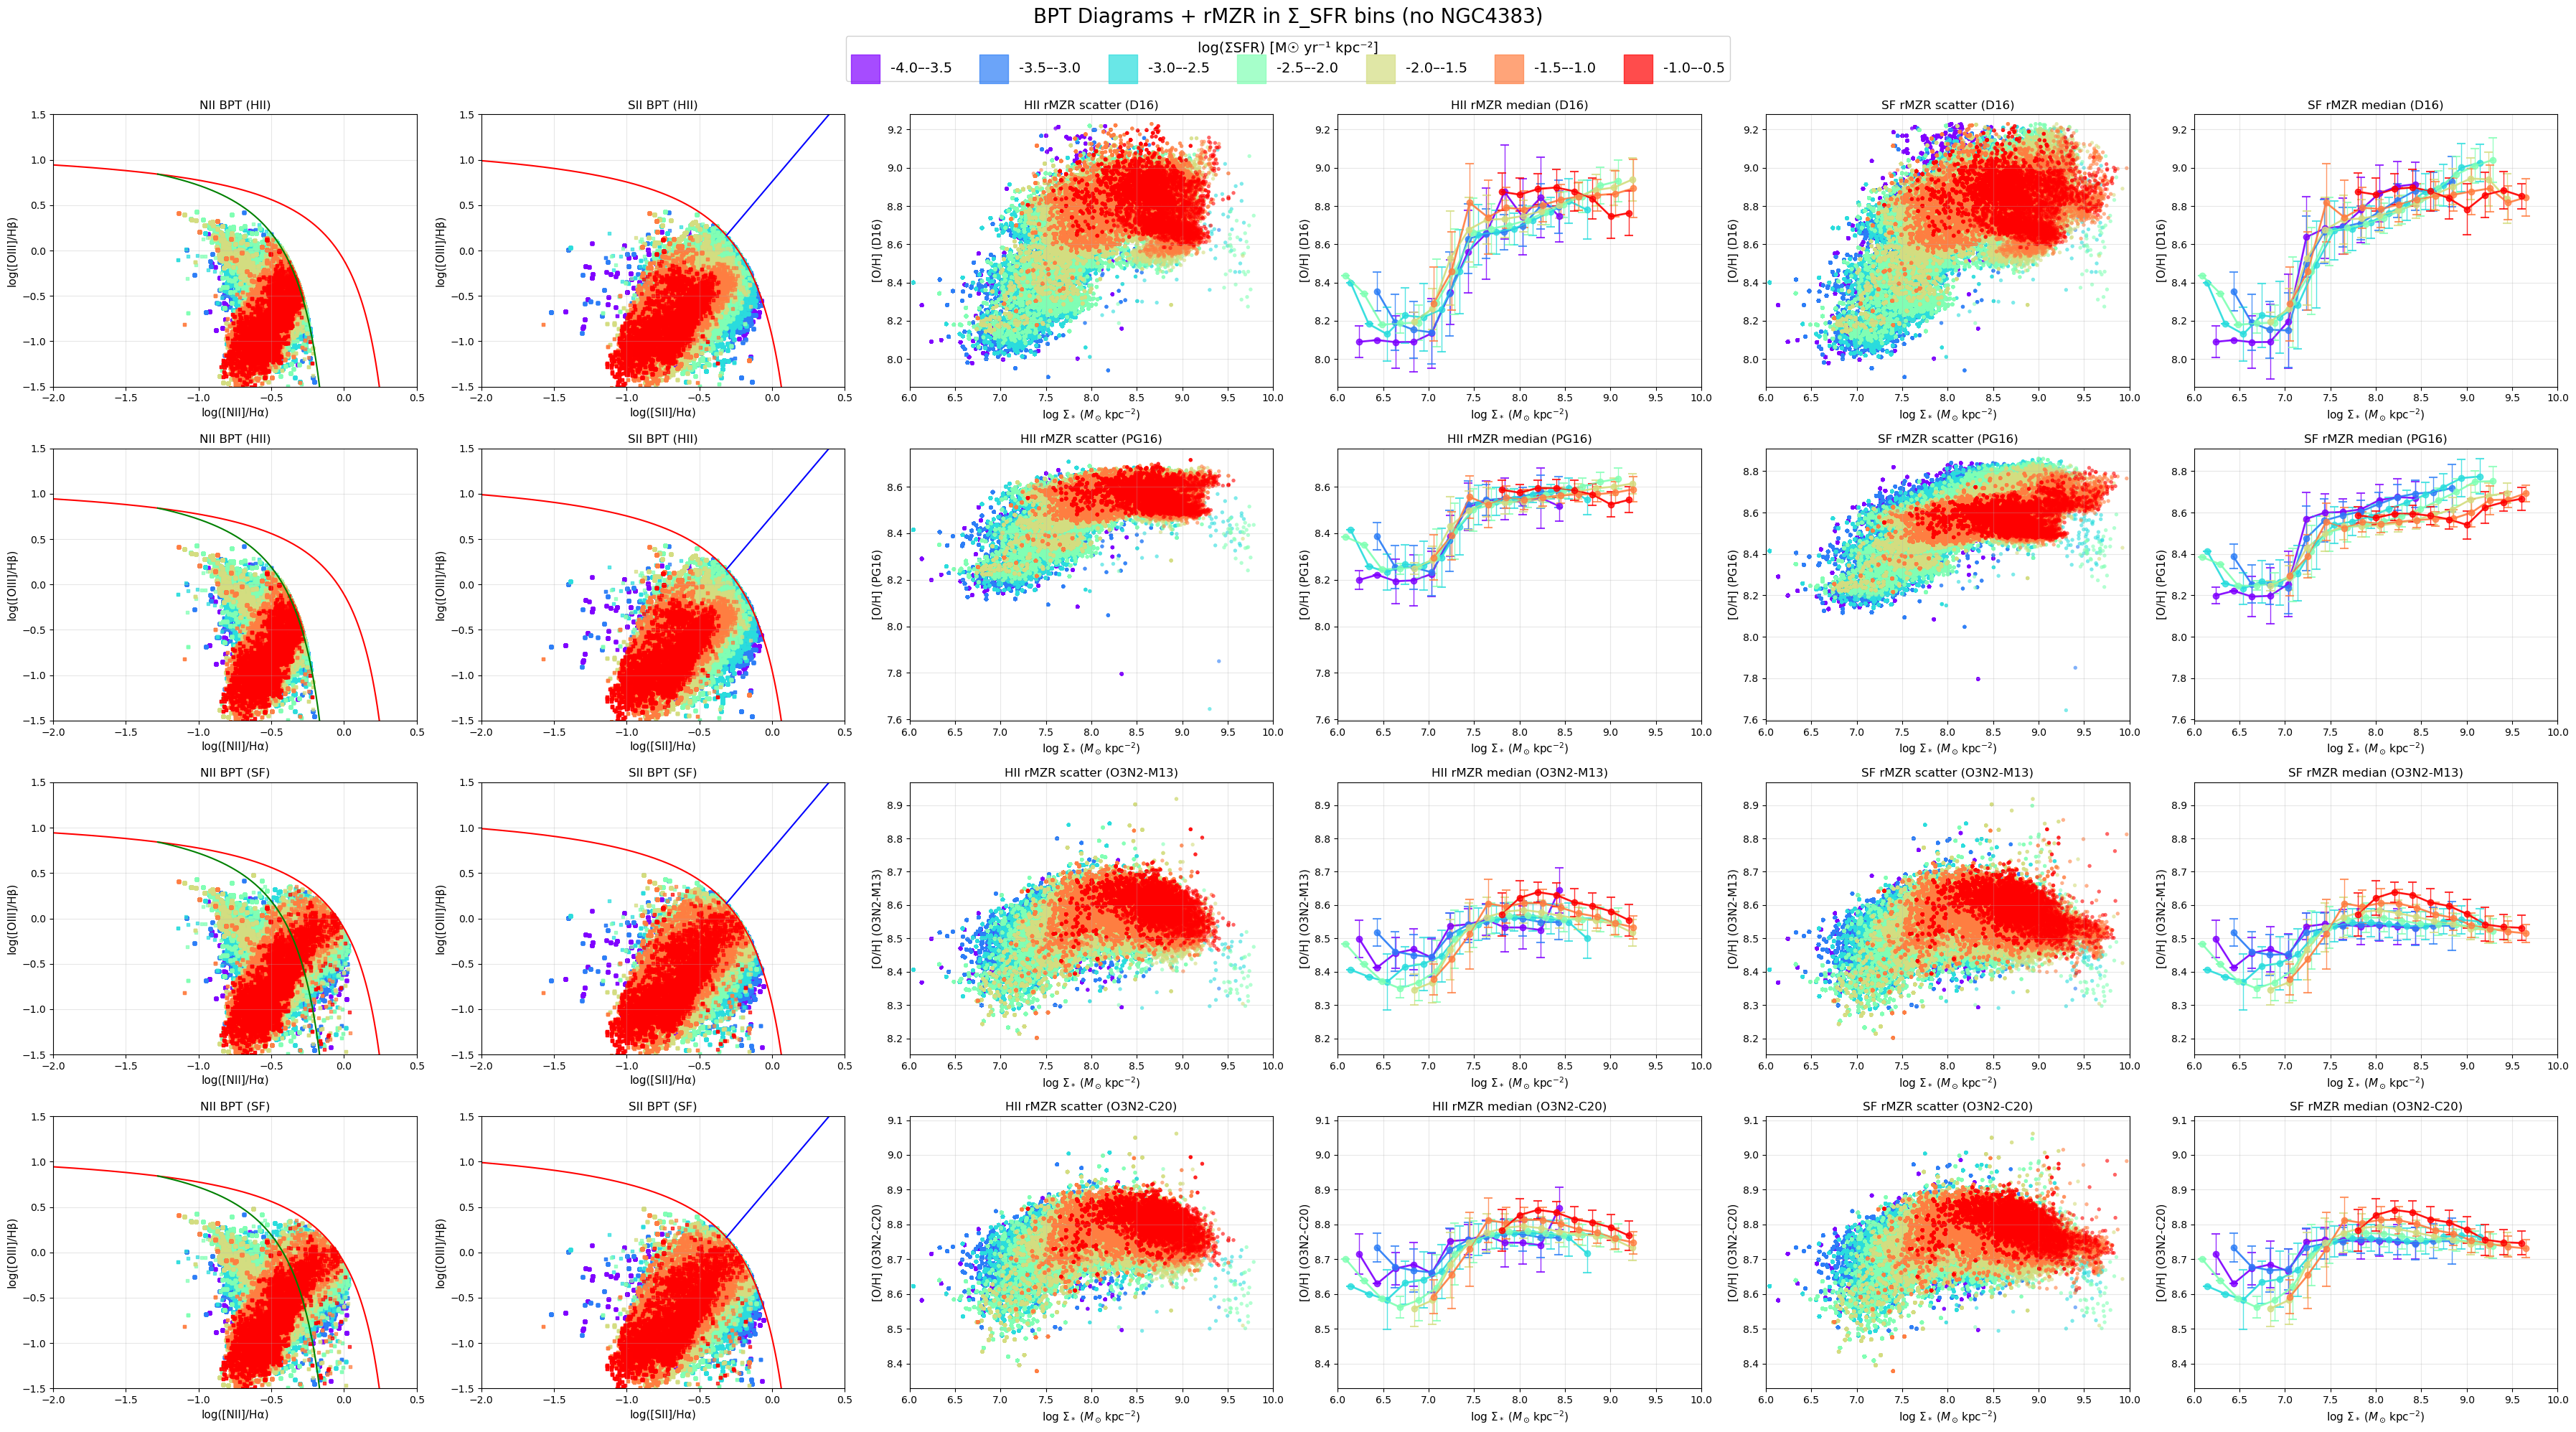


Successfully created 4x6 subplot figure from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


In [6]:
# ------------------------------------------------------------------
# Combined Analysis: BPT Diagrams + rMZR behavior in Σ_SFR bins
# Layout: 4 rows x 6 columns
# Left 2 columns: BPT diagrams (NII and SII) for HII (rows 0-1) and SF (rows 2-3)
# Right 4 columns: rMZR scatter + median for HII and SF
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

# BPT reference line functions
def kewley01_N2(x):
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):
    return 1.89*x + 0.76

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for both HII and SF regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
        # Emission lines
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
            HB4861_FLUX_corr, HA6562_FLUX_corr, OIII5006_FLUX_corr, 
            NII6583_FLUX_corr, SII6716_FLUX_corr, SII6730_FLUX_corr)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins if f.name.split('_')[0] != 'NGC4383']

# Collect all spaxels - MZR data
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

all_logSigmaM_SF = []
all_logSigmaSFR_SF = []
all_oh_d16_SF = []
all_oh_pg16_SF = []
all_oh_o3n2_m13_SF = []
all_oh_o3n2_c20_SF = []

# Collect all spaxels - BPT data
all_logN2_hii = []
all_logO3_hii = []
all_logS2_hii = []
all_logSFR_hii = []

all_logN2_sf = []
all_logO3_sf = []
all_logS2_sf = []
all_logSFR_sf = []

print("Collecting data from all galaxies...")
for gal in galaxies:
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        # Load all data
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
         logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
         HB, HA, OIII, NII, SII6716, SII6730) = load_maps_all_calibrations(gal)

        # Common mask for HII
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) &
                           np.isfinite(HB) & np.isfinite(HA) & np.isfinite(OIII) & 
                           np.isfinite(NII) & np.isfinite(SII6716) & np.isfinite(SII6730))
        
        # Common mask for SF
        common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                          np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                          np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF) &
                          np.isfinite(HB) & np.isfinite(HA) & np.isfinite(OIII) & 
                          np.isfinite(NII) & np.isfinite(SII6716) & np.isfinite(SII6730))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)}, SF={np.sum(common_mask_SF)} pixels")
        
        # Append MZR data - HII
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
        
        # Append MZR data - SF
        all_logSigmaM_SF.extend(logSigmaM[common_mask_SF].flatten())
        all_logSigmaSFR_SF.extend(logSigmaSFR_SF[common_mask_SF].flatten())
        all_oh_d16_SF.extend(oh_d16_SF[common_mask_SF].flatten())
        all_oh_pg16_SF.extend(oh_pg16_SF[common_mask_SF].flatten())
        all_oh_o3n2_m13_SF.extend(oh_o3n2_m13_SF[common_mask_SF].flatten())
        all_oh_o3n2_c20_SF.extend(oh_o3n2_c20_SF[common_mask_SF].flatten())
        
        # Calculate BPT ratios - HII
        logN2_hii = np.log10(NII[common_mask_HII] / HA[common_mask_HII])
        logO3_hii = np.log10(OIII[common_mask_HII] / HB[common_mask_HII])
        logS2_hii = np.log10((SII6716[common_mask_HII] + SII6730[common_mask_HII]) / HA[common_mask_HII])
        
        all_logN2_hii.extend(logN2_hii.flatten())
        all_logO3_hii.extend(logO3_hii.flatten())
        all_logS2_hii.extend(logS2_hii.flatten())
        all_logSFR_hii.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        
        # Calculate BPT ratios - SF
        logN2_sf = np.log10(NII[common_mask_SF] / HA[common_mask_SF])
        logO3_sf = np.log10(OIII[common_mask_SF] / HB[common_mask_SF])
        logS2_sf = np.log10((SII6716[common_mask_SF] + SII6730[common_mask_SF]) / HA[common_mask_SF])
        
        all_logN2_sf.extend(logN2_sf.flatten())
        all_logO3_sf.extend(logO3_sf.flatten())
        all_logS2_sf.extend(logS2_sf.flatten())
        all_logSFR_sf.extend(logSigmaSFR_SF[common_mask_SF].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays - MZR
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

all_logSigmaM_SF = np.array(all_logSigmaM_SF)
all_logSigmaSFR_SF = np.array(all_logSigmaSFR_SF)
all_oh_d16_SF = np.array(all_oh_d16_SF)
all_oh_pg16_SF = np.array(all_oh_pg16_SF)
all_oh_o3n2_m13_SF = np.array(all_oh_o3n2_m13_SF)
all_oh_o3n2_c20_SF = np.array(all_oh_o3n2_c20_SF)

# Convert to numpy arrays - BPT
all_logN2_hii = np.array(all_logN2_hii)
all_logO3_hii = np.array(all_logO3_hii)
all_logS2_hii = np.array(all_logS2_hii)
all_logSFR_hii = np.array(all_logSFR_hii)

all_logN2_sf = np.array(all_logN2_sf)
all_logO3_sf = np.array(all_logO3_sf)
all_logS2_sf = np.array(all_logS2_sf)
all_logSFR_sf = np.array(all_logSFR_sf)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")
print(f"Total combined pixels (SF): {len(all_logSigmaM_SF)}")

# Define Σ_SFR bins
sfr_bin_edges = np.arange(-4, 0.0, 0.5)
n_bins = len(sfr_bin_edges) - 1
colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# Assign SFR bin indices
sfr_bin_indices_hii = np.digitize(all_logSFR_hii, sfr_bin_edges) - 1
sfr_bin_indices_hii = np.clip(sfr_bin_indices_hii, 0, n_bins - 1)

sfr_bin_indices_sf = np.digitize(all_logSFR_sf, sfr_bin_edges) - 1
sfr_bin_indices_sf = np.clip(sfr_bin_indices_sf, 0, n_bins - 1)

# BPT classifications - HII
mask_N2_HII_bpt = all_logO3_hii <= kewley01_N2(all_logN2_hii)
mask_S2_HII_bpt = all_logO3_hii <= kewley01_S2(all_logS2_hii)

# BPT classifications - SF
mask_N2_SF_bpt = all_logO3_sf <= kewley01_N2(all_logN2_sf)
mask_S2_SF_bpt = all_logO3_sf <= kewley01_S2(all_logS2_sf)

# BPT reference lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# Create figure with 4 rows x 6 columns
fig, axes = plt.subplots(4, 6, figsize=(36, 20))

# Calibrations for rMZR
calibrations_HII = [
    (all_oh_d16_HII, 'D16'),
    (all_oh_pg16_HII, 'PG16'),
    (all_oh_o3n2_m13_HII, 'O3N2-M13'),
    (all_oh_o3n2_c20_HII, 'O3N2-C20')
]

calibrations_SF = [
    (all_oh_d16_SF, 'D16'),
    (all_oh_pg16_SF, 'PG16'),
    (all_oh_o3n2_m13_SF, 'O3N2-M13'),
    (all_oh_o3n2_c20_SF, 'O3N2-C20')
]

legend_handles = []
legend_labels = []

# ==== ROWS 0-1: HII BPT DIAGRAMS ====
for row_idx in range(2):
    # NII BPT - HII (column 0)
    ax = axes[row_idx, 0]
    for i in range(n_bins):
        bin_mask = mask_N2_HII_bpt & (sfr_bin_indices_hii == i)
        if np.sum(bin_mask) > 0:
            scatter = ax.scatter(all_logN2_hii[bin_mask], all_logO3_hii[bin_mask], 
                       color=colors[i], marker=',', s=8, alpha=0.7)
            if row_idx == 0 and len(legend_handles) < n_bins:
                legend_handles.append(scatter)
                legend_labels.append(f'{sfr_bin_edges[i]:.1f}–{sfr_bin_edges[i+1]:.1f}')
    
    ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5)
    ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5)
    ax.set_xlabel('log([NII]/Hα)', fontsize=11)
    ax.set_ylabel('log([OIII]/Hβ)', fontsize=11)
    ax.set_xlim(-2.0, 0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f'NII BPT (HII)', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # SII BPT - HII (column 1)
    ax = axes[row_idx, 1]
    for i in range(n_bins):
        bin_mask = mask_S2_HII_bpt & (sfr_bin_indices_hii == i)
        if np.sum(bin_mask) > 0:
            ax.scatter(all_logS2_hii[bin_mask], all_logO3_hii[bin_mask], 
                       color=colors[i], marker=',', s=8, alpha=0.7)
    
    ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=1.5)
    ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=1.5)
    ax.set_xlabel('log([SII]/Hα)', fontsize=11)
    ax.set_ylabel('log([OIII]/Hβ)', fontsize=11)
    ax.set_xlim(-2.0, 0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f'SII BPT (HII)', fontsize=12)
    ax.grid(True, alpha=0.3)

# ==== ROWS 2-3: SF BPT DIAGRAMS ====
for row_idx in range(2, 4):
    # NII BPT - SF (column 0)
    ax = axes[row_idx, 0]
    for i in range(n_bins):
        bin_mask = mask_N2_SF_bpt & (sfr_bin_indices_sf == i)
        if np.sum(bin_mask) > 0:
            ax.scatter(all_logN2_sf[bin_mask], all_logO3_sf[bin_mask], 
                       color=colors[i], marker=',', s=8, alpha=0.7)
    
    ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5)
    ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5)
    ax.set_xlabel('log([NII]/Hα)', fontsize=11)
    ax.set_ylabel('log([OIII]/Hβ)', fontsize=11)
    ax.set_xlim(-2.0, 0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f'NII BPT (SF)', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # SII BPT - SF (column 1)
    ax = axes[row_idx, 1]
    for i in range(n_bins):
        bin_mask = mask_S2_SF_bpt & (sfr_bin_indices_sf == i)
        if np.sum(bin_mask) > 0:
            ax.scatter(all_logS2_sf[bin_mask], all_logO3_sf[bin_mask], 
                       color=colors[i], marker=',', s=8, alpha=0.7)
    
    ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=1.5)
    ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=1.5)
    ax.set_xlabel('log([SII]/Hα)', fontsize=11)
    ax.set_ylabel('log([OIII]/Hβ)', fontsize=11)
    ax.set_xlim(-2.0, 0.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f'SII BPT (SF)', fontsize=12)
    ax.grid(True, alpha=0.3)

# ==== ALL ROWS: rMZR PLOTS (columns 2-5) ====
for row_idx, ((oh_data_HII, calib_name_HII), (oh_data_SF, calib_name_SF)) in enumerate(zip(calibrations_HII, calibrations_SF)):
    print(f"\nProcessing {calib_name_HII} calibration:")
    
    # Axes for this row
    ax_scatter_HII = axes[row_idx, 2]  # Column 2: HII scatter
    ax_median_HII = axes[row_idx, 3]   # Column 3: HII median
    ax_scatter_SF = axes[row_idx, 4]   # Column 4: SF scatter
    ax_median_SF = axes[row_idx, 5]    # Column 5: SF median
    
    # Calculate y-axis ranges
    all_y_HII = []
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        in_bin = (all_logSigmaSFR_HII >= bin_start) & (all_logSigmaSFR_HII < bin_end)
        if np.sum(in_bin) >= 10:
            all_y_HII.extend(oh_data_HII[in_bin])
    ylim_HII = (np.min(all_y_HII) - 0.05, np.max(all_y_HII) + 0.05) if all_y_HII else (8.0, 9.3)
    
    all_y_SF = []
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        in_bin = (all_logSigmaSFR_SF >= bin_start) & (all_logSigmaSFR_SF < bin_end)
        if np.sum(in_bin) >= 10:
            all_y_SF.extend(oh_data_SF[in_bin])
    ylim_SF = (np.min(all_y_SF) - 0.05, np.max(all_y_SF) + 0.05) if all_y_SF else (8.0, 9.3)
    
    # Plot each SFR bin
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        # HII scatter
        in_bin_HII = (all_logSigmaSFR_HII >= bin_start) & (all_logSigmaSFR_HII < bin_end)
        if np.sum(in_bin_HII) >= 10:
            ax_scatter_HII.scatter(all_logSigmaM_HII[in_bin_HII], oh_data_HII[in_bin_HII], 
                                  c=[colors[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
            
            # HII median
            mass_centers, medians, stds, counts, valid_idx = calculate_binned_stats(
                all_logSigmaM_HII[in_bin_HII], oh_data_HII[in_bin_HII])
            if len(mass_centers) > 0:
                ax_median_HII.errorbar(mass_centers, medians, yerr=stds, color=colors[i], 
                                      marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_idx) - 1):
                    if valid_idx[j + 1] - valid_idx[j] == 1:
                        ax_median_HII.plot([mass_centers[j], mass_centers[j + 1]], 
                                          [medians[j], medians[j + 1]], color=colors[i], linewidth=2, alpha=0.8)
        
        # SF scatter
        in_bin_SF = (all_logSigmaSFR_SF >= bin_start) & (all_logSigmaSFR_SF < bin_end)
        if np.sum(in_bin_SF) >= 10:
            ax_scatter_SF.scatter(all_logSigmaM_SF[in_bin_SF], oh_data_SF[in_bin_SF], 
                                 c=[colors[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
            
            # SF median
            mass_centers, medians, stds, counts, valid_idx = calculate_binned_stats(
                all_logSigmaM_SF[in_bin_SF], oh_data_SF[in_bin_SF])
            if len(mass_centers) > 0:
                ax_median_SF.errorbar(mass_centers, medians, yerr=stds, color=colors[i], 
                                     marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                for j in range(len(valid_idx) - 1):
                    if valid_idx[j + 1] - valid_idx[j] == 1:
                        ax_median_SF.plot([mass_centers[j], mass_centers[j + 1]], 
                                         [medians[j], medians[j + 1]], color=colors[i], linewidth=2, alpha=0.8)
    
    # Format axes
    for ax, ylabel in [(ax_scatter_HII, f'[O/H] ({calib_name_HII})'), (ax_median_HII, f'[O/H] ({calib_name_HII})')]:
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xlim(6, 10)
        ax.set_ylim(ylim_HII)
        ax.grid(True, alpha=0.3)
    
    for ax, ylabel in [(ax_scatter_SF, f'[O/H] ({calib_name_SF})'), (ax_median_SF, f'[O/H] ({calib_name_SF})')]:
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xlim(6, 10)
        ax.set_ylim(ylim_SF)
        ax.grid(True, alpha=0.3)
    
    ax_scatter_HII.set_title(f'HII rMZR scatter ({calib_name_HII})', fontsize=12)
    ax_median_HII.set_title(f'HII rMZR median ({calib_name_HII})', fontsize=12)
    ax_scatter_SF.set_title(f'SF rMZR scatter ({calib_name_SF})', fontsize=12)
    ax_median_SF.set_title(f'SF rMZR median ({calib_name_SF})', fontsize=12)

# Add shared legend
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
          ncol=min(len(legend_labels), 8), fontsize=14, framealpha=0.9, 
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=14, markerscale=10)

fig.suptitle(f'BPT Diagrams + rMZR in Σ_SFR bins (no NGC4383)', fontsize=20, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"\nSuccessfully created 4x6 subplot figure from {len(galaxies)} galaxies")
print(f"Galaxies included: {', '.join(galaxies)}")

  IC3392: 14884 HII pixels, 19776 SF pixels
  NGC4064: 6820 HII pixels, 15383 SF pixels
  NGC4064: 6820 HII pixels, 15383 SF pixels
  NGC4192: 145934 HII pixels, 275015 SF pixels
  NGC4192: 145934 HII pixels, 275015 SF pixels
  NGC4293: 3854 HII pixels, 8590 SF pixels
  NGC4293: 3854 HII pixels, 8590 SF pixels
  NGC4298: 156350 HII pixels, 181696 SF pixels
  NGC4298: 156350 HII pixels, 181696 SF pixels
  NGC4330: 42566 HII pixels, 43709 SF pixels
  NGC4383: 75127 HII pixels, 75127 SF pixels
  NGC4330: 42566 HII pixels, 43709 SF pixels
  NGC4383: 75127 HII pixels, 75127 SF pixels
  NGC4396: 81728 HII pixels, 81734 SF pixels
  NGC4396: 81728 HII pixels, 81734 SF pixels
  NGC4419: 6886 HII pixels, 22002 SF pixels
  NGC4419: 6886 HII pixels, 22002 SF pixels
  NGC4457: 6000 HII pixels, 24136 SF pixels
  NGC4501: 260854 HII pixels, 419043 SF pixels
  NGC4457: 6000 HII pixels, 24136 SF pixels
  NGC4501: 260854 HII pixels, 419043 SF pixels
  NGC4522: 39354 HII pixels, 40444 SF pixels
  NGC4694

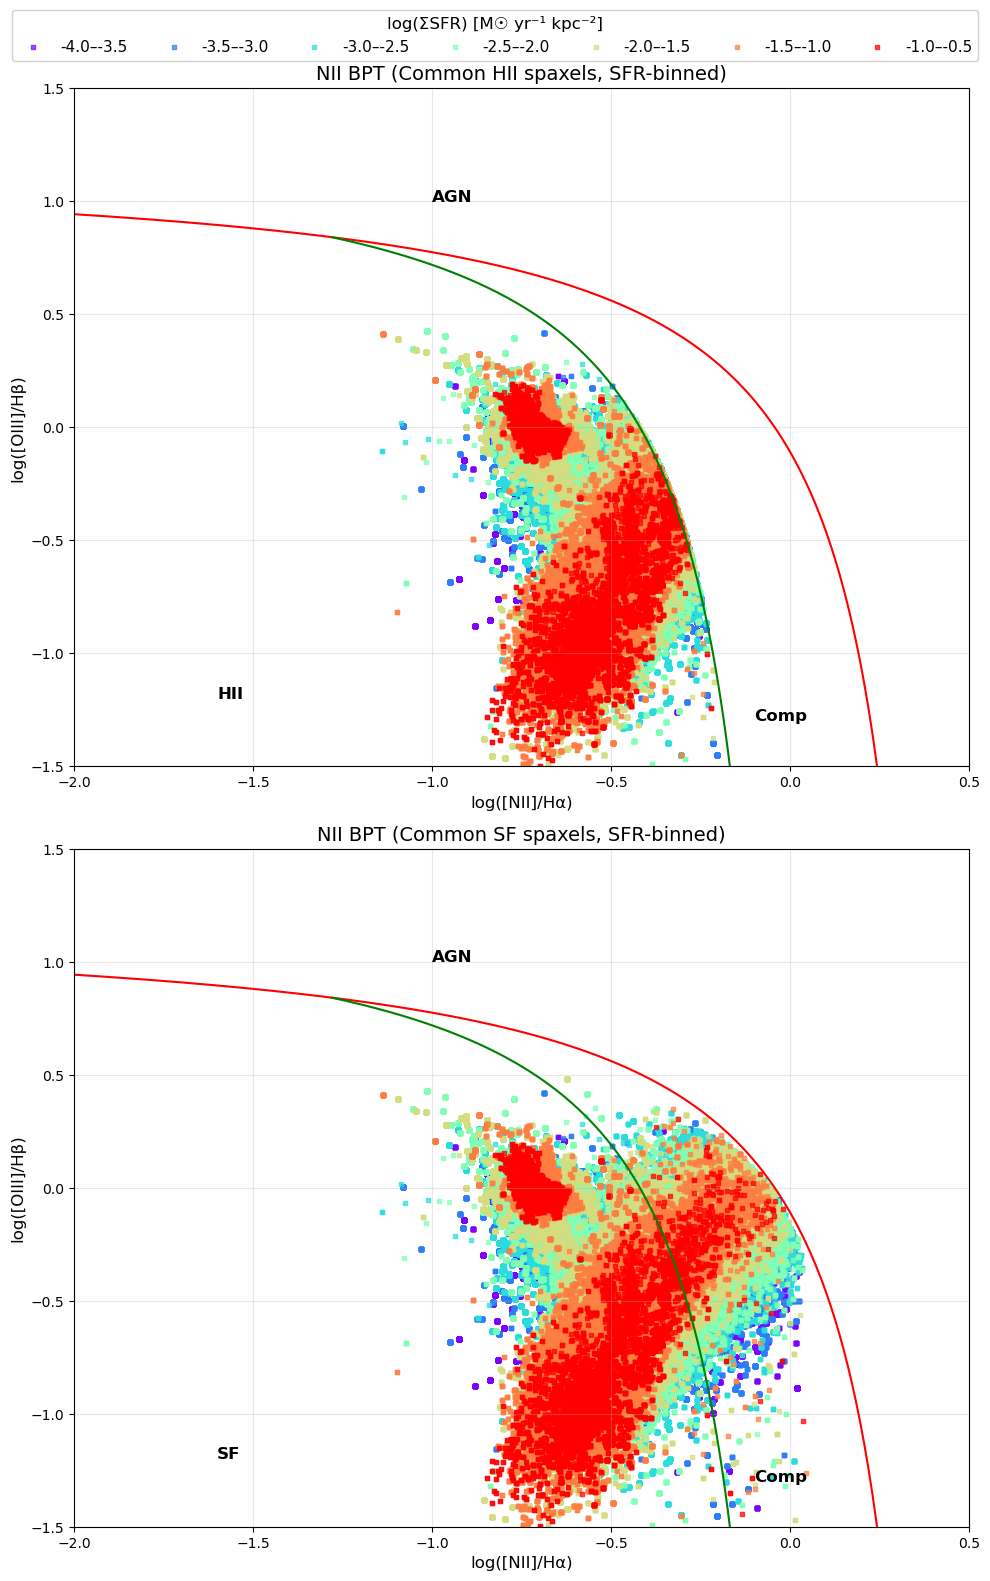


=== Combined NII BPT Diagram Summary ===

HII Regions:
  N2 BPT - Total HII: 852984 (100.0%)

SF Regions:
  N2 BPT - Total SF: 1244927 (100.0%)

SFR bin breakdown for HII spaxels:
  Bin 0 (-4.0 to -3.5): N2_HII=17433
  Bin 1 (-3.5 to -3.0): N2_HII=102034
  Bin 2 (-3.0 to -2.5): N2_HII=226160
  Bin 3 (-2.5 to -2.0): N2_HII=264390
  Bin 4 (-2.0 to -1.5): N2_HII=173746
  Bin 5 (-1.5 to -1.0): N2_HII=54930
  Bin 6 (-1.0 to -0.5): N2_HII=9730

SFR bin breakdown for SF spaxels:
  Bin 0 (-4.0 to -3.5): N2_SF=47752
  Bin 1 (-3.5 to -3.0): N2_SF=216369
  Bin 2 (-3.0 to -2.5): N2_SF=362340
  Bin 3 (-2.5 to -2.0): N2_SF=345565
  Bin 4 (-2.0 to -1.5): N2_SF=198393
  Bin 5 (-1.5 to -1.0): N2_SF=58027
  Bin 6 (-1.0 to -0.5): N2_SF=10223

Successfully created combined NII BPT diagrams from 14 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698


In [7]:
# ------------------------------------------------------------------
# Combined Analysis: NII BPT Diagram Only - Color-coded by SFR bins
# Collect all spaxels from all galaxies
# Uses common spaxels across all 4 metallicity calibrations
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

# BPT reference line functions
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30

# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)

# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Collect all spaxels from all galaxies - HII
all_logN2_hii = []
all_logO3_hii = []
all_logSFR_hii = []

# Collect all spaxels from all galaxies - SF
all_logN2_sf = []
all_logO3_sf = []
all_logSFR_sf = []

print("Collecting data from all galaxies...")
for gal in galaxies:
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')

    if gas_file.exists() and bin_file.exists():
        # Load maps for this galaxy
        with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
            logSigmaM = h['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
            # HII
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            oh_d16_HII = h['O_H_D16_HII'].data
            oh_pg16_HII = h['O_H_PG16_HII'].data
            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
            oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
            
            # SF
            logSigmaSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
            oh_d16_SF = h['O_H_D16_SF'].data
            oh_pg16_SF = h['O_H_PG16_SF'].data
            oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
            oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
            
            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
            HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
            OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        
        # Find common spaxels for HII
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) &
                       np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                       np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr))
        
        # Find common spaxels for SF
        common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                       np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                       np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF) &
                       np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                       np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr))
        
        print(f"  {gal}: {np.sum(common_mask_HII)} HII pixels, {np.sum(common_mask_SF)} SF pixels")
        
        # Apply common_mask to get valid spaxels - HII
        HB_common_HII = HB4861_FLUX_corr[common_mask_HII]
        HA_common_HII = HA6562_FLUX_corr[common_mask_HII]
        OIII_common_HII = OIII5006_FLUX_corr[common_mask_HII]
        NII_common_HII = NII6583_FLUX_corr[common_mask_HII]
        
        # Apply common_mask to get valid spaxels - SF
        HB_common_SF = HB4861_FLUX_corr[common_mask_SF]
        HA_common_SF = HA6562_FLUX_corr[common_mask_SF]
        OIII_common_SF = OIII5006_FLUX_corr[common_mask_SF]
        NII_common_SF = NII6583_FLUX_corr[common_mask_SF]
        
        # Calculate line ratios - HII
        logN2_hii = np.log10(NII_common_HII / HA_common_HII)
        logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
        logSFR_hii = logSigmaSFR_HII[common_mask_HII]
        
        # Calculate line ratios - SF
        logN2_sf = np.log10(NII_common_SF / HA_common_SF)
        logO3_sf = np.log10(OIII_common_SF / HB_common_SF)
        logSFR_sf = logSigmaSFR_SF[common_mask_SF]
        
        # Append to combined arrays - HII
        all_logN2_hii.extend(logN2_hii.flatten())
        all_logO3_hii.extend(logO3_hii.flatten())
        all_logSFR_hii.extend(logSFR_hii.flatten())
        
        # Append to combined arrays - SF
        all_logN2_sf.extend(logN2_sf.flatten())
        all_logO3_sf.extend(logO3_sf.flatten())
        all_logSFR_sf.extend(logSFR_sf.flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays - HII
all_logN2_hii = np.array(all_logN2_hii)
all_logO3_hii = np.array(all_logO3_hii)
all_logSFR_hii = np.array(all_logSFR_hii)

# Convert to numpy arrays - SF
all_logN2_sf = np.array(all_logN2_sf)
all_logO3_sf = np.array(all_logO3_sf)
all_logSFR_sf = np.array(all_logSFR_sf)

print(f"\nTotal combined HII pixels: {len(all_logN2_hii)}")
print(f"Total combined SF pixels: {len(all_logN2_sf)}")

# Create SFR bins for color coding
sfr_bin_edges = np.arange(-4, 0, 0.5)
n_bins = len(sfr_bin_edges) - 1

# Assign SFR bin indices - HII
sfr_bin_indices_hii = np.full_like(all_logSFR_hii, -1, dtype=int)

for i in range(n_bins):
    bin_mask = (all_logSFR_hii >= sfr_bin_edges[i]) & (all_logSFR_hii < sfr_bin_edges[i+1])
    if i == n_bins - 1:
        bin_mask = (all_logSFR_hii >= sfr_bin_edges[i]) & (all_logSFR_hii <= sfr_bin_edges[i+1])
    sfr_bin_indices_hii[bin_mask] = i

# Assign SFR bin indices - SF
sfr_bin_indices_sf = np.full_like(all_logSFR_sf, -1, dtype=int)

for i in range(n_bins):
    bin_mask = (all_logSFR_sf >= sfr_bin_edges[i]) & (all_logSFR_sf < sfr_bin_edges[i+1])
    if i == n_bins - 1:
        bin_mask = (all_logSFR_sf >= sfr_bin_edges[i]) & (all_logSFR_sf <= sfr_bin_edges[i+1])
    sfr_bin_indices_sf[bin_mask] = i

# Apply BPT classifications - HII
mask_N2_HII = all_logO3_hii <= kauff03_N2(all_logN2_hii)
mask_N2_Comp = (all_logO3_hii > kauff03_N2(all_logN2_hii)) & (all_logO3_hii <= kewley01_N2(all_logN2_hii))
mask_N2_AGN = all_logO3_hii > kewley01_N2(all_logN2_hii)

mask_HII_N2 = mask_N2_HII | mask_N2_Comp

# Apply BPT classifications - SF
mask_N2_HII_sf = all_logO3_sf <= kauff03_N2(all_logN2_sf)
mask_N2_Comp_sf = (all_logO3_sf > kauff03_N2(all_logN2_sf)) & (all_logO3_sf <= kewley01_N2(all_logN2_sf))
mask_N2_AGN_sf = all_logO3_sf > kewley01_N2(all_logN2_sf)

mask_HII_N2_sf = mask_N2_HII_sf | mask_N2_Comp_sf

# Create BPT diagrams with 2 rows, 1 column
fig, axes = plt.subplots(2, 1, figsize=(10, 16))

colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# Collect legend handles and labels for shared legend
legend_handles = []
legend_labels = []

# ===== TOP ROW: HII REGIONS =====

ax = axes[0]

for i in range(n_bins):
    bin_hii_mask = mask_HII_N2 & (sfr_bin_indices_hii == i)
    if np.sum(bin_hii_mask) > 0:
        scatter = ax.scatter(all_logN2_hii[bin_hii_mask], all_logO3_hii[bin_hii_mask], 
                   color=colors[i], marker=',', s=8, alpha=0.7)
        # Store handles and labels
        legend_handles.append(scatter)
        legend_labels.append(f'{sfr_bin_edges[i]:.1f}–{sfr_bin_edges[i+1]:.1f}')

ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')

hii_count_N2 = np.sum(mask_HII_N2)
total_common_hii = len(all_logN2_hii)
hii_percent_N2 = hii_count_N2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax.set_xlabel('log([NII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f'NII BPT (Common HII spaxels, SFR-binned)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
ax.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# ===== BOTTOM ROW: SF REGIONS =====

ax = axes[1]

for i in range(n_bins):
    bin_sf_mask = mask_HII_N2_sf & (sfr_bin_indices_sf == i)
    if np.sum(bin_sf_mask) > 0:
        ax.scatter(all_logN2_sf[bin_sf_mask], all_logO3_sf[bin_sf_mask], 
                   color=colors[i], marker=',', s=8, alpha=0.7)

ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')

sf_count_N2 = np.sum(mask_HII_N2_sf)
total_common_sf = len(all_logN2_sf)
sf_percent_N2 = sf_count_N2 / total_common_sf * 100 if total_common_sf > 0 else 0

ax.set_xlabel('log([NII]/Hα)', fontsize=12)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title(f'NII BPT (Common SF spaxels, SFR-binned)', fontsize=14)
ax.text(-1.6, -1.2, 'SF', fontsize=12, fontweight='bold')
ax.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add shared legend at the top horizontally
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.99),
          ncol=min(len(legend_labels), 7), fontsize=11, framealpha=0.9, 
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the legend at the top
# plt.savefig('Combined_NII_BPT_diagrams_SFR_binned_HII_SF.png', dpi=300)
# plt.savefig('Combined_NII_BPT_diagrams_SFR_binned_HII_SF.pdf')
plt.show()

# Print summary statistics
print(f"\n=== Combined NII BPT Diagram Summary ===")
print(f"\nHII Regions:")
print(f"  N2 BPT - Total HII: {hii_count_N2} ({hii_percent_N2:.1f}%)")

print(f"\nSF Regions:")
print(f"  N2 BPT - Total SF: {sf_count_N2} ({sf_percent_N2:.1f}%)")

# Print SFR bin breakdown
print(f"\nSFR bin breakdown for HII spaxels:")
for i in range(n_bins):
    bin_hii_n2 = np.sum(mask_HII_N2 & (sfr_bin_indices_hii == i))
    print(f"  Bin {i} ({sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}): N2_HII={bin_hii_n2}")

print(f"\nSFR bin breakdown for SF spaxels:")
for i in range(n_bins):
    bin_sf_n2 = np.sum(mask_HII_N2_sf & (sfr_bin_indices_sf == i))
    print(f"  Bin {i} ({sfr_bin_edges[i]:.1f} to {sfr_bin_edges[i+1]:.1f}): N2_SF={bin_sf_n2}")

print(f"\nSuccessfully created combined NII BPT diagrams from {len(galaxies)} galaxies")
print(f"Galaxies included: {', '.join(galaxies)}")


In [8]:
# # ------------------------------------------------------------------
# # MASTER COMBINED FIGURE: Cell 7 (2x1 NII BPT) + Cell 6 (4x4 rMZR grid)
# # Layout: GridSpec with 4 rows x 6 columns
# # Columns 0-1: Cell 7 content (Standalone NII BPT - HII rows 0-1, SF rows 2-3)
# # Columns 2-5: Cell 6 rMZR content (4 calibrations x 4 plots each row)
# # ------------------------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path
# from astropy.io import fits
# import scipy.stats as stats
# import matplotlib.gridspec as gridspec

# # BPT reference line functions
# def kewley01_N2(x):
#     return 0.61/(x-0.47) + 1.19

# def kauff03_N2(x):
#     return 0.61/(x-0.05) + 1.30

# def kewley01_S2(x):
#     return 0.72/(x-0.32) + 1.30

# def kewley06_Sy_LIN(x):
#     return 1.89*x + 0.76

# def load_maps_all_calibrations(gal):
#     """Load all metallicity calibrations for both HII and SF regions"""
#     with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
#         sigM = h['LOGMASS_SURFACE_DENSITY'].data
#     with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
#         # HII regions
#         sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
#         oh_d16_HII = h['O_H_D16_HII'].data
#         oh_pg16_HII = h['O_H_PG16_HII'].data
#         oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
#         oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
#         # SF regions
#         sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
#         oh_d16_SF = h['O_H_D16_SF'].data
#         oh_pg16_SF = h['O_H_PG16_SF'].data
#         oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
#         oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
#         # Emission lines
#         HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
#         HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
#         OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
#         NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
#         SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
#         SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
#     return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
#             sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
#             HB4861_FLUX_corr, HA6562_FLUX_corr, OIII5006_FLUX_corr, 
#             NII6583_FLUX_corr, SII6716_FLUX_corr, SII6730_FLUX_corr)

# def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
#     """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
#     x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
#     mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
#     mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
#     medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    
#     for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
#         in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
#         y_in_bin = y_data[in_mass_bin]
        
#         if len(y_in_bin) >= min_pixels:
#             medians.append(np.median(y_in_bin))
#             stds.append(np.std(y_in_bin))
#             counts.append(len(y_in_bin))
#             valid_centers.append(mass_bin_centers[i])
#             valid_bin_indices.append(i)
    
#     return (np.array(valid_centers), np.array(medians), np.array(stds), 
#             np.array(counts), np.array(valid_bin_indices))

# # Get all galaxies
# bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
# galaxies = [f.name.split('_')[0] for f in bins if f.name.split('_')[0] != 'NGC4383']

# # Collect all spaxels - MZR data
# all_logSigmaM_HII = []
# all_logSigmaSFR_HII = []
# all_oh_d16_HII = []
# all_oh_pg16_HII = []
# all_oh_o3n2_m13_HII = []
# all_oh_o3n2_c20_HII = []

# all_logSigmaM_SF = []
# all_logSigmaSFR_SF = []
# all_oh_d16_SF = []
# all_oh_pg16_SF = []
# all_oh_o3n2_m13_SF = []
# all_oh_o3n2_c20_SF = []

# # Collect all spaxels - BPT data
# all_logN2_hii = []
# all_logO3_hii = []
# all_logS2_hii = []
# all_logSFR_hii = []

# all_logN2_sf = []
# all_logO3_sf = []
# all_logS2_sf = []
# all_logSFR_sf = []

# print("Collecting data from all galaxies...")
# for gal in galaxies:
#     bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
#     gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

#     if bin_file.exists() and gas_file.exists():
#         # Load all data
#         (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
#          logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
#          HB, HA, OIII, NII, SII6716, SII6730) = load_maps_all_calibrations(gal)

#         # Common mask for HII
#         common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
#                            np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
#                            np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) &
#                            np.isfinite(HB) & np.isfinite(HA) & np.isfinite(OIII) & 
#                            np.isfinite(NII) & np.isfinite(SII6716) & np.isfinite(SII6730))
        
#         # Common mask for SF
#         common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
#                           np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
#                           np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF) &
#                           np.isfinite(HB) & np.isfinite(HA) & np.isfinite(OIII) & 
#                           np.isfinite(NII) & np.isfinite(SII6716) & np.isfinite(SII6730))
        
#         print(f"  {gal}: HII={np.sum(common_mask_HII)}, SF={np.sum(common_mask_SF)} pixels")
        
#         # Append MZR data - HII
#         all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
#         all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
#         all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
#         all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
#         all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
#         all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
        
#         # Append MZR data - SF
#         all_logSigmaM_SF.extend(logSigmaM[common_mask_SF].flatten())
#         all_logSigmaSFR_SF.extend(logSigmaSFR_SF[common_mask_SF].flatten())
#         all_oh_d16_SF.extend(oh_d16_SF[common_mask_SF].flatten())
#         all_oh_pg16_SF.extend(oh_pg16_SF[common_mask_SF].flatten())
#         all_oh_o3n2_m13_SF.extend(oh_o3n2_m13_SF[common_mask_SF].flatten())
#         all_oh_o3n2_c20_SF.extend(oh_o3n2_c20_SF[common_mask_SF].flatten())
        
#         # Calculate BPT ratios - HII
#         logN2_hii = np.log10(NII[common_mask_HII] / HA[common_mask_HII])
#         logO3_hii = np.log10(OIII[common_mask_HII] / HB[common_mask_HII])
#         logS2_hii = np.log10((SII6716[common_mask_HII] + SII6730[common_mask_HII]) / HA[common_mask_HII])
        
#         all_logN2_hii.extend(logN2_hii.flatten())
#         all_logO3_hii.extend(logO3_hii.flatten())
#         all_logS2_hii.extend(logS2_hii.flatten())
#         all_logSFR_hii.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        
#         # Calculate BPT ratios - SF
#         logN2_sf = np.log10(NII[common_mask_SF] / HA[common_mask_SF])
#         logO3_sf = np.log10(OIII[common_mask_SF] / HB[common_mask_SF])
#         logS2_sf = np.log10((SII6716[common_mask_SF] + SII6730[common_mask_SF]) / HA[common_mask_SF])
        
#         all_logN2_sf.extend(logN2_sf.flatten())
#         all_logO3_sf.extend(logO3_sf.flatten())
#         all_logS2_sf.extend(logS2_sf.flatten())
#         all_logSFR_sf.extend(logSigmaSFR_SF[common_mask_SF].flatten())
#     else:
#         print(f"  {gal}: Data files not found")

# # Convert to numpy arrays - MZR
# all_logSigmaM_HII = np.array(all_logSigmaM_HII)
# all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
# all_oh_d16_HII = np.array(all_oh_d16_HII)
# all_oh_pg16_HII = np.array(all_oh_pg16_HII)
# all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
# all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

# all_logSigmaM_SF = np.array(all_logSigmaM_SF)
# all_logSigmaSFR_SF = np.array(all_logSigmaSFR_SF)
# all_oh_d16_SF = np.array(all_oh_d16_SF)
# all_oh_pg16_SF = np.array(all_oh_pg16_SF)
# all_oh_o3n2_m13_SF = np.array(all_oh_o3n2_m13_SF)
# all_oh_o3n2_c20_SF = np.array(all_oh_o3n2_c20_SF)

# # Convert to numpy arrays - BPT
# all_logN2_hii = np.array(all_logN2_hii)
# all_logO3_hii = np.array(all_logO3_hii)
# all_logS2_hii = np.array(all_logS2_hii)
# all_logSFR_hii = np.array(all_logSFR_hii)

# all_logN2_sf = np.array(all_logN2_sf)
# all_logO3_sf = np.array(all_logO3_sf)
# all_logS2_sf = np.array(all_logS2_sf)
# all_logSFR_sf = np.array(all_logSFR_sf)

# print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")
# print(f"Total combined pixels (SF): {len(all_logSigmaM_SF)}")

# # Define Σ_SFR bins
# sfr_bin_edges = np.arange(-4, 0.0, 0.5)
# n_bins = len(sfr_bin_edges) - 1
# colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# # Assign SFR bin indices
# sfr_bin_indices_hii = np.digitize(all_logSFR_hii, sfr_bin_edges) - 1
# sfr_bin_indices_hii = np.clip(sfr_bin_indices_hii, 0, n_bins - 1)

# sfr_bin_indices_sf = np.digitize(all_logSFR_sf, sfr_bin_edges) - 1
# sfr_bin_indices_sf = np.clip(sfr_bin_indices_sf, 0, n_bins - 1)

# # BPT classifications
# mask_N2_HII_bpt = all_logO3_hii <= kewley01_N2(all_logN2_hii)
# mask_S2_HII_bpt = all_logO3_hii <= kewley01_S2(all_logS2_hii)
# mask_N2_SF_bpt = all_logO3_sf <= kewley01_N2(all_logN2_sf)
# mask_S2_SF_bpt = all_logO3_sf <= kewley01_S2(all_logS2_sf)

# # Additional classifications for cell 7
# mask_N2_HII = all_logO3_hii <= kauff03_N2(all_logN2_hii)
# mask_N2_Comp = (all_logO3_hii > kauff03_N2(all_logN2_hii)) & (all_logO3_hii <= kewley01_N2(all_logN2_hii))
# mask_N2_AGN = all_logO3_hii > kewley01_N2(all_logN2_hii)
# mask_HII_N2 = mask_N2_HII | mask_N2_Comp

# mask_N2_HII_sf = all_logO3_sf <= kauff03_N2(all_logN2_sf)
# mask_N2_Comp_sf = (all_logO3_sf > kauff03_N2(all_logN2_sf)) & (all_logO3_sf <= kewley01_N2(all_logN2_sf))
# mask_N2_AGN_sf = all_logO3_sf > kewley01_N2(all_logN2_sf)
# mask_HII_N2_sf = mask_N2_HII_sf | mask_N2_Comp_sf

# # BPT reference lines
# x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
# x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
# x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
# x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# # Create figure with GridSpec: 4 rows x 6 columns
# fig = plt.figure(figsize=(32, 20))
# gs = gridspec.GridSpec(4, 6, figure=fig, wspace=0.3, hspace=0.3)

# # Calibrations for rMZR
# calibrations_HII = [
#     (all_oh_d16_HII, 'D16'),
#     (all_oh_pg16_HII, 'PG16'),
#     (all_oh_o3n2_m13_HII, 'O3N2-M13'),
#     (all_oh_o3n2_c20_HII, 'O3N2-C20')
# ]

# calibrations_SF = [
#     (all_oh_d16_SF, 'D16'),
#     (all_oh_pg16_SF, 'PG16'),
#     (all_oh_o3n2_m13_SF, 'O3N2-M13'),
#     (all_oh_o3n2_c20_SF, 'O3N2-C20')
# ]

# legend_handles = []
# legend_labels = []

# # ==== CELL 7 CONTENT: Columns 0-1 (Standalone NII BPT) ====

# # HII NII BPT (rows 0-1, columns 0-1)
# ax_hii_standalone = fig.add_subplot(gs[0:2, 0:2])
# for i in range(n_bins):
#     bin_hii_mask = mask_HII_N2 & (sfr_bin_indices_hii == i)
#     if np.sum(bin_hii_mask) > 0:
#         scatter = ax_hii_standalone.scatter(all_logN2_hii[bin_hii_mask], all_logO3_hii[bin_hii_mask], 
#                    color=colors[i], marker=',', s=8, alpha=0.7)
#         if len(legend_handles) < n_bins:
#             legend_handles.append(scatter)
#             legend_labels.append(f'{sfr_bin_edges[i]:.1f}–{sfr_bin_edges[i+1]:.1f}')

# ax_hii_standalone.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
# ax_hii_standalone.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')

# hii_count_N2 = np.sum(mask_HII_N2)
# total_common_hii = len(all_logN2_hii)
# hii_percent_N2 = hii_count_N2 / total_common_hii * 100 if total_common_hii > 0 else 0

# ax_hii_standalone.set_xlabel('log([NII]/Hα)', fontsize=12)
# ax_hii_standalone.set_ylabel('log([OIII]/Hβ)', fontsize=12)
# ax_hii_standalone.set_xlim(-2.0, 0.5)
# ax_hii_standalone.set_ylim(-1.5, 1.5)
# ax_hii_standalone.set_title(f'NII BPT (HII)', fontsize=14)
# ax_hii_standalone.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
# ax_hii_standalone.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
# ax_hii_standalone.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
# ax_hii_standalone.grid(True, alpha=0.3)

# # SF NII BPT (rows 2-3, columns 0-1)
# ax_sf_standalone = fig.add_subplot(gs[2:4, 0:2])
# for i in range(n_bins):
#     bin_sf_mask = mask_HII_N2_sf & (sfr_bin_indices_sf == i)
#     if np.sum(bin_sf_mask) > 0:
#         ax_sf_standalone.scatter(all_logN2_sf[bin_sf_mask], all_logO3_sf[bin_sf_mask], 
#                    color=colors[i], marker=',', s=8, alpha=0.7)

# ax_sf_standalone.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
# ax_sf_standalone.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')

# sf_count_N2 = np.sum(mask_HII_N2_sf)
# total_common_sf = len(all_logN2_sf)
# sf_percent_N2 = sf_count_N2 / total_common_sf * 100 if total_common_sf > 0 else 0

# ax_sf_standalone.set_xlabel('log([NII]/Hα)', fontsize=12)
# ax_sf_standalone.set_ylabel('log([OIII]/Hβ)', fontsize=12)
# ax_sf_standalone.set_xlim(-2.0, 0.5)
# ax_sf_standalone.set_ylim(-1.5, 1.5)
# ax_sf_standalone.set_title(f'NII BPT (SF)', fontsize=14)
# ax_sf_standalone.text(-1.6, -1.2, 'SF', fontsize=12, fontweight='bold')
# ax_sf_standalone.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
# ax_sf_standalone.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
# ax_sf_standalone.grid(True, alpha=0.3)

# # ==== CELL 6 CONTENT: rMZR PLOTS (columns 2-5) ====
# for row_idx, ((oh_data_HII, calib_name_HII), (oh_data_SF, calib_name_SF)) in enumerate(zip(calibrations_HII, calibrations_SF)):
#     print(f"\nProcessing {calib_name_HII} calibration:")
    
#     # Axes for this row
#     ax_scatter_HII = fig.add_subplot(gs[row_idx, 2])
#     ax_median_HII = fig.add_subplot(gs[row_idx, 3])
#     ax_scatter_SF = fig.add_subplot(gs[row_idx, 4])
#     ax_median_SF = fig.add_subplot(gs[row_idx, 5])
    
#     # Calculate y-axis ranges
#     all_y_HII = []
#     for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
#         in_bin = (all_logSigmaSFR_HII >= bin_start) & (all_logSigmaSFR_HII < bin_end)
#         if np.sum(in_bin) >= 10:
#             all_y_HII.extend(oh_data_HII[in_bin])
#     ylim_HII = (np.min(all_y_HII) - 0.05, np.max(all_y_HII) + 0.05) if all_y_HII else (8.0, 9.3)
    
#     all_y_SF = []
#     for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
#         in_bin = (all_logSigmaSFR_SF >= bin_start) & (all_logSigmaSFR_SF < bin_end)
#         if np.sum(in_bin) >= 10:
#             all_y_SF.extend(oh_data_SF[in_bin])
#     ylim_SF = (np.min(all_y_SF) - 0.05, np.max(all_y_SF) + 0.05) if all_y_SF else (8.0, 9.3)
    
#     # Plot each SFR bin
#     for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
#         # HII scatter
#         in_bin_HII = (all_logSigmaSFR_HII >= bin_start) & (all_logSigmaSFR_HII < bin_end)
#         if np.sum(in_bin_HII) >= 10:
#             ax_scatter_HII.scatter(all_logSigmaM_HII[in_bin_HII], oh_data_HII[in_bin_HII], 
#                                   c=[colors[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
            
#             # HII median
#             mass_centers, medians, stds, counts, valid_idx = calculate_binned_stats(
#                 all_logSigmaM_HII[in_bin_HII], oh_data_HII[in_bin_HII])
#             if len(mass_centers) > 0:
#                 ax_median_HII.errorbar(mass_centers, medians, yerr=stds, color=colors[i], 
#                                       marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
#                 for j in range(len(valid_idx) - 1):
#                     if valid_idx[j + 1] - valid_idx[j] == 1:
#                         ax_median_HII.plot([mass_centers[j], mass_centers[j + 1]], 
#                                           [medians[j], medians[j + 1]], color=colors[i], linewidth=2, alpha=0.8)
        
#         # SF scatter
#         in_bin_SF = (all_logSigmaSFR_SF >= bin_start) & (all_logSigmaSFR_SF < bin_end)
#         if np.sum(in_bin_SF) >= 10:
#             ax_scatter_SF.scatter(all_logSigmaM_SF[in_bin_SF], oh_data_SF[in_bin_SF], 
#                                  c=[colors[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
            
#             # SF median
#             mass_centers, medians, stds, counts, valid_idx = calculate_binned_stats(
#                 all_logSigmaM_SF[in_bin_SF], oh_data_SF[in_bin_SF])
#             if len(mass_centers) > 0:
#                 ax_median_SF.errorbar(mass_centers, medians, yerr=stds, color=colors[i], 
#                                      marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
#                 for j in range(len(valid_idx) - 1):
#                     if valid_idx[j + 1] - valid_idx[j] == 1:
#                         ax_median_SF.plot([mass_centers[j], mass_centers[j + 1]], 
#                                          [medians[j], medians[j + 1]], color=colors[i], linewidth=2, alpha=0.8)
    
#     # Format axes
#     for ax, ylabel in [(ax_scatter_HII, f'[O/H] ({calib_name_HII})'), (ax_median_HII, f'[O/H] ({calib_name_HII})')]:
#         ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
#         ax.set_ylabel(ylabel, fontsize=11)
#         ax.set_xlim(6, 10)
#         ax.set_ylim(ylim_HII)
#         ax.grid(True, alpha=0.3)
    
#     for ax, ylabel in [(ax_scatter_SF, f'[O/H] ({calib_name_SF})'), (ax_median_SF, f'[O/H] ({calib_name_SF})')]:
#         ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
#         ax.set_ylabel(ylabel, fontsize=11)
#         ax.set_xlim(6, 10)
#         ax.set_ylim(ylim_SF)
#         ax.grid(True, alpha=0.3)
    
#     ax_scatter_HII.set_title(f'HII rMZR scatter ({calib_name_HII})', fontsize=12)
#     ax_median_HII.set_title(f'HII rMZR median ({calib_name_HII})', fontsize=12)
#     ax_scatter_SF.set_title(f'SF rMZR scatter ({calib_name_SF})', fontsize=12)
#     ax_median_SF.set_title(f'SF rMZR median ({calib_name_SF})', fontsize=12)

# # Add shared legend
# fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.95),
#           ncol=min(len(legend_labels), 8), fontsize=14, framealpha=0.9, 
#           title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=14, markerscale=10)

# fig.suptitle(f'COMBINED: NII BPT + rMZR in Σ_SFR bins (no NGC4383)', fontsize=20, y=0.98)
# plt.tight_layout(rect=[0, 0, 1, 1])
# plt.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rMZR_HII_vs_SF.png', dpi=600)
# plt.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rMZR_HII_vs_SF.pdf')
# plt.show()

# print(f"\n=== MASTER COMBINED FIGURE SUMMARY ===")
# print(f"Successfully created combined figure from {len(galaxies)} galaxies")
# print(f"Galaxies included: {', '.join(galaxies)}")
# print(f"\nHII Regions - N2 BPT: {hii_count_N2} ({hii_percent_N2:.1f}%)")
# print(f"SF Regions - N2 BPT: {sf_count_N2} ({sf_percent_N2:.1f}%)")

  IC3392: HII=14884, SF=19776 pixels
  IC3392: HII=14884, SF=19776 pixels
  NGC4064: HII=6820, SF=15383 pixels
  NGC4064: HII=6820, SF=15383 pixels
  NGC4192: HII=145934, SF=275015 pixels
  NGC4192: HII=145934, SF=275015 pixels
  NGC4293: HII=3854, SF=8590 pixels
  NGC4293: HII=3854, SF=8590 pixels
  NGC4298: HII=156350, SF=181696 pixels
  NGC4298: HII=156350, SF=181696 pixels
  NGC4330: HII=42566, SF=43709 pixels
  NGC4330: HII=42566, SF=43709 pixels
  NGC4396: HII=81728, SF=81734 pixels
  NGC4396: HII=81728, SF=81734 pixels
  NGC4419: HII=6886, SF=22002 pixels
  NGC4419: HII=6886, SF=22002 pixels
  NGC4457: HII=6000, SF=24136 pixels
  NGC4501: HII=260854, SF=419043 pixels
  NGC4457: HII=6000, SF=24136 pixels
  NGC4501: HII=260854, SF=419043 pixels
  NGC4522: HII=39354, SF=40444 pixels
  NGC4522: HII=39354, SF=40444 pixels
  NGC4694: HII=2585, SF=3851 pixels
  NGC4698: HII=10042, SF=34421 pixels
  NGC4694: HII=2585, SF=3851 pixels
  NGC4698: HII=10042, SF=34421 pixels

Total combined 

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_24862/530111349.py:391: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


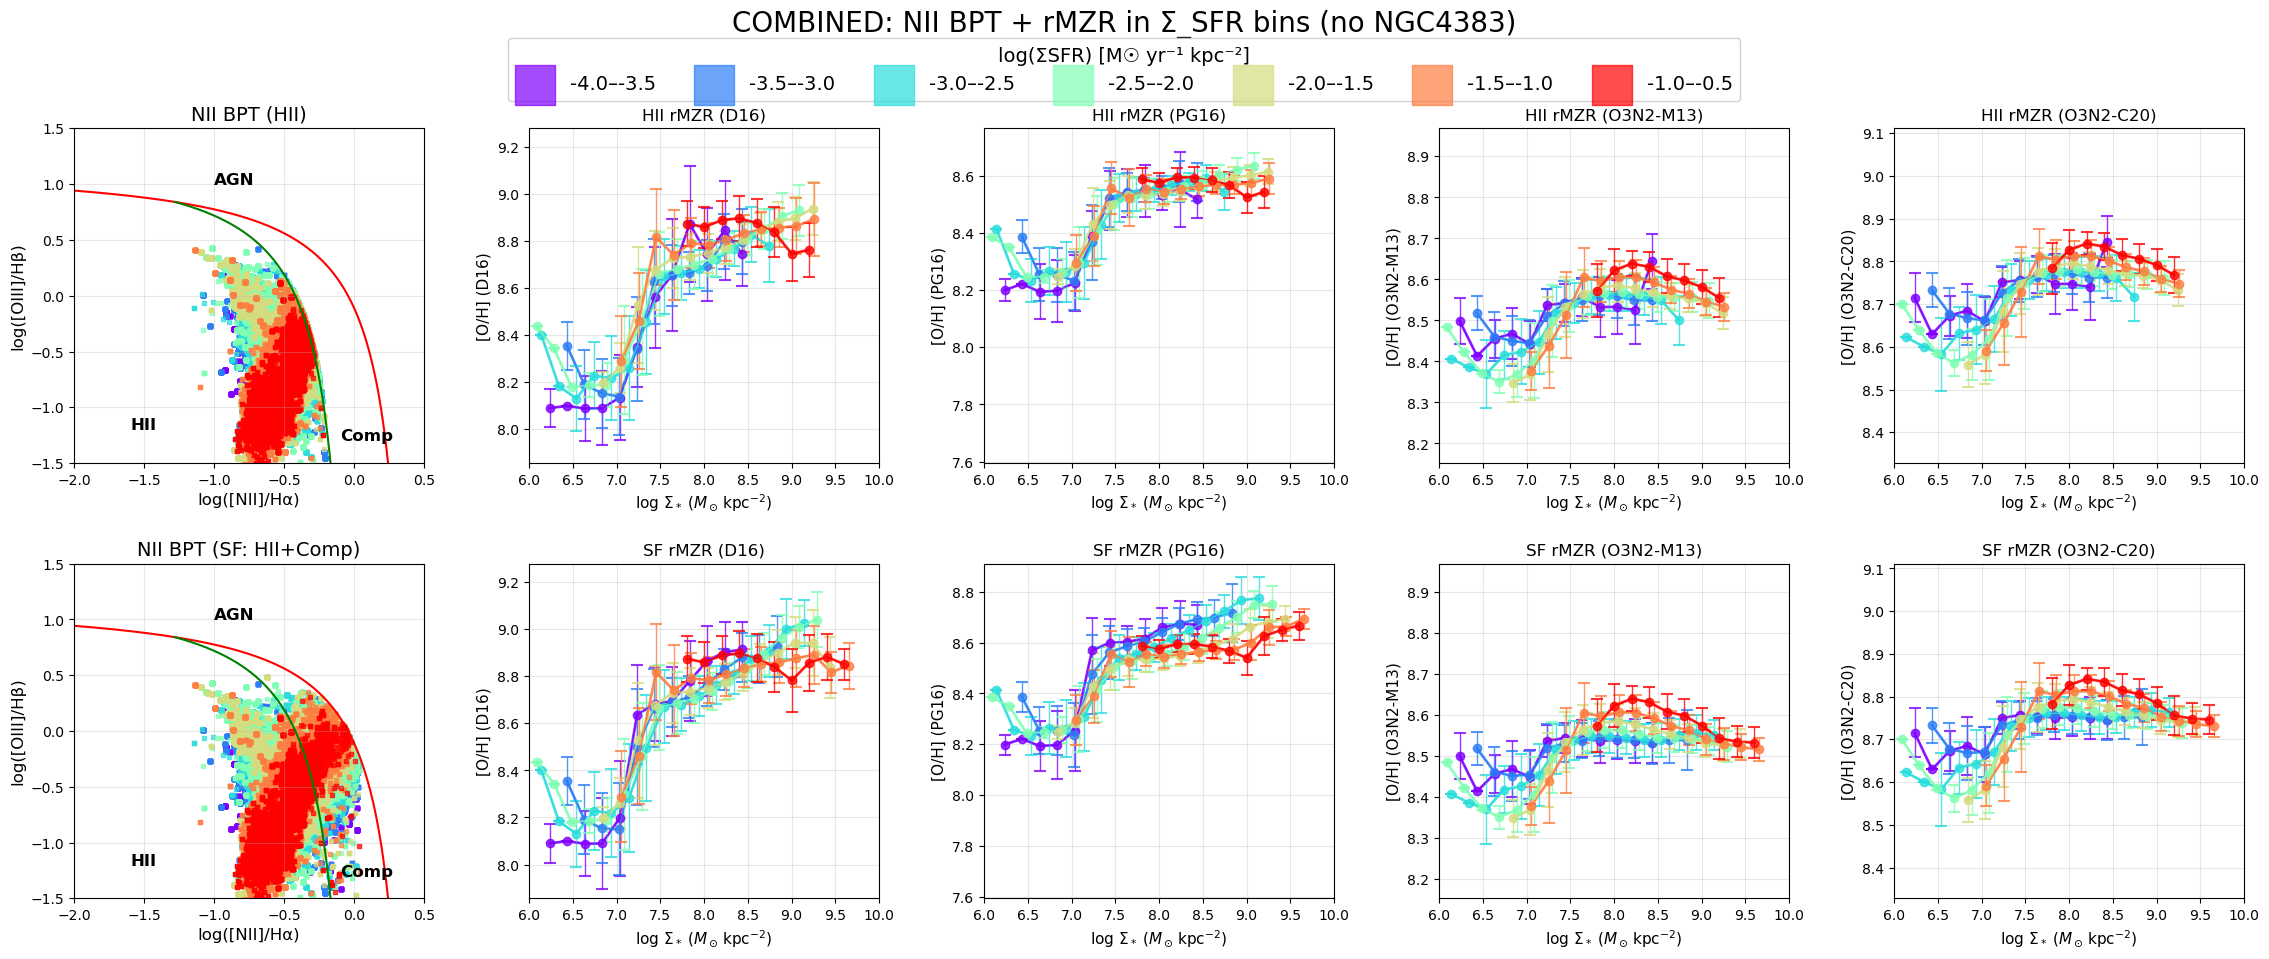


=== MASTER COMBINED FIGURE SUMMARY ===
Successfully created combined figure from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698

HII Regions - N2 BPT: 777857 (100.0%)
SF Regions - N2 BPT: 1169800 (100.0%)


In [9]:
# ------------------------------------------------------------------
# MASTER COMBINED FIGURE: NII BPT + rMZR plots
# Layout: GridSpec with 2 rows x 5 columns
# Column 0: NII BPT (HII top, SF bottom)
# Columns 1-4: rMZR for 4 calibrations (HII top, SF bottom)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import matplotlib.gridspec as gridspec

# BPT reference line functions
def kewley01_N2(x):
    return 0.61/(x-0.47) + 1.19

def kauff03_N2(x):
    return 0.61/(x-0.05) + 1.30

def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30

def kewley06_Sy_LIN(x):
    return 1.89*x + 0.76

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for both HII and SF regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
        # SF regions
        sigSFR_SF = h['LOGSFR_SURFACE_DENSITY_SF'].data
        oh_d16_SF = h['O_H_D16_SF'].data
        oh_pg16_SF = h['O_H_PG16_SF'].data
        oh_o3n2_m13_SF = h['O_H_O3N2_M13_SF'].data
        oh_o3n2_c20_SF = h['O_H_O3N2_C20_SF'].data
        # Emission lines
        HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data
        HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data
        OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
        NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
        SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
        SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
            sigSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
            HB4861_FLUX_corr, HA6562_FLUX_corr, OIII5006_FLUX_corr, 
            NII6583_FLUX_corr, SII6716_FLUX_corr, SII6730_FLUX_corr)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=50):
    """Calculate median and std in stellar mass bins - only keep bins with >= 50 unique datapoints"""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    mass_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2
    
    medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
    
    for i, (bin_start, bin_end) in enumerate(zip(mass_bin_edges[:-1], mass_bin_edges[1:])):
        in_mass_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_mass_bin]
        
        if len(y_in_bin) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(mass_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins if f.name.split('_')[0] != 'NGC4383']

# Collect all spaxels - MZR data
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

all_logSigmaM_SF = []
all_logSigmaSFR_SF = []
all_oh_d16_SF = []
all_oh_pg16_SF = []
all_oh_o3n2_m13_SF = []
all_oh_o3n2_c20_SF = []

# Collect all spaxels - BPT data
all_logN2_hii = []
all_logO3_hii = []
all_logS2_hii = []
all_logSFR_hii = []

all_logN2_sf = []
all_logO3_sf = []
all_logS2_sf = []
all_logSFR_sf = []

print("Collecting data from all galaxies...")
for gal in galaxies:
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        # Load all data
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII,
         logSigmaSFR_SF, oh_d16_SF, oh_pg16_SF, oh_o3n2_m13_SF, oh_o3n2_c20_SF,
         HB, HA, OIII, NII, SII6716, SII6730) = load_maps_all_calibrations(gal)

        # Common mask for HII
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII) &
                           np.isfinite(HB) & np.isfinite(HA) & np.isfinite(OIII) & 
                           np.isfinite(NII) & np.isfinite(SII6716) & np.isfinite(SII6730))
        
        # Common mask for SF
        common_mask_SF = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_SF) & 
                          np.isfinite(oh_d16_SF) & np.isfinite(oh_pg16_SF) & 
                          np.isfinite(oh_o3n2_m13_SF) & np.isfinite(oh_o3n2_c20_SF) &
                          np.isfinite(HB) & np.isfinite(HA) & np.isfinite(OIII) & 
                          np.isfinite(NII) & np.isfinite(SII6716) & np.isfinite(SII6730))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)}, SF={np.sum(common_mask_SF)} pixels")
        
        # Append MZR data - HII
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
        
        # Append MZR data - SF
        all_logSigmaM_SF.extend(logSigmaM[common_mask_SF].flatten())
        all_logSigmaSFR_SF.extend(logSigmaSFR_SF[common_mask_SF].flatten())
        all_oh_d16_SF.extend(oh_d16_SF[common_mask_SF].flatten())
        all_oh_pg16_SF.extend(oh_pg16_SF[common_mask_SF].flatten())
        all_oh_o3n2_m13_SF.extend(oh_o3n2_m13_SF[common_mask_SF].flatten())
        all_oh_o3n2_c20_SF.extend(oh_o3n2_c20_SF[common_mask_SF].flatten())
        
        # Calculate BPT ratios - HII
        logN2_hii = np.log10(NII[common_mask_HII] / HA[common_mask_HII])
        logO3_hii = np.log10(OIII[common_mask_HII] / HB[common_mask_HII])
        logS2_hii = np.log10((SII6716[common_mask_HII] + SII6730[common_mask_HII]) / HA[common_mask_HII])
        
        all_logN2_hii.extend(logN2_hii.flatten())
        all_logO3_hii.extend(logO3_hii.flatten())
        all_logS2_hii.extend(logS2_hii.flatten())
        all_logSFR_hii.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        
        # Calculate BPT ratios - SF
        logN2_sf = np.log10(NII[common_mask_SF] / HA[common_mask_SF])
        logO3_sf = np.log10(OIII[common_mask_SF] / HB[common_mask_SF])
        logS2_sf = np.log10((SII6716[common_mask_SF] + SII6730[common_mask_SF]) / HA[common_mask_SF])
        
        all_logN2_sf.extend(logN2_sf.flatten())
        all_logO3_sf.extend(logO3_sf.flatten())
        all_logS2_sf.extend(logS2_sf.flatten())
        all_logSFR_sf.extend(logSigmaSFR_SF[common_mask_SF].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays - MZR
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

all_logSigmaM_SF = np.array(all_logSigmaM_SF)
all_logSigmaSFR_SF = np.array(all_logSigmaSFR_SF)
all_oh_d16_SF = np.array(all_oh_d16_SF)
all_oh_pg16_SF = np.array(all_oh_pg16_SF)
all_oh_o3n2_m13_SF = np.array(all_oh_o3n2_m13_SF)
all_oh_o3n2_c20_SF = np.array(all_oh_o3n2_c20_SF)

# Convert to numpy arrays - BPT
all_logN2_hii = np.array(all_logN2_hii)
all_logO3_hii = np.array(all_logO3_hii)
all_logS2_hii = np.array(all_logS2_hii)
all_logSFR_hii = np.array(all_logSFR_hii)

all_logN2_sf = np.array(all_logN2_sf)
all_logO3_sf = np.array(all_logO3_sf)
all_logS2_sf = np.array(all_logS2_sf)
all_logSFR_sf = np.array(all_logSFR_sf)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")
print(f"Total combined pixels (SF): {len(all_logSigmaM_SF)}")

# Define Σ_SFR bins
sfr_bin_edges = np.arange(-4, 0.0, 0.5)
n_bins = len(sfr_bin_edges) - 1
colors = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# Assign SFR bin indices
sfr_bin_indices_hii = np.digitize(all_logSFR_hii, sfr_bin_edges) - 1
sfr_bin_indices_hii = np.clip(sfr_bin_indices_hii, 0, n_bins - 1)

sfr_bin_indices_sf = np.digitize(all_logSFR_sf, sfr_bin_edges) - 1
sfr_bin_indices_sf = np.clip(sfr_bin_indices_sf, 0, n_bins - 1)

# BPT classifications
mask_N2_HII_bpt = all_logO3_hii <= kewley01_N2(all_logN2_hii)
mask_S2_HII_bpt = all_logO3_hii <= kewley01_S2(all_logS2_hii)
mask_N2_SF_bpt = all_logO3_sf <= kewley01_N2(all_logN2_sf)
mask_S2_SF_bpt = all_logO3_sf <= kewley01_S2(all_logS2_sf)

# Additional classifications for cell 7
mask_N2_HII = all_logO3_hii <= kauff03_N2(all_logN2_hii)
mask_N2_Comp = (all_logO3_hii > kauff03_N2(all_logN2_hii)) & (all_logO3_hii <= kewley01_N2(all_logN2_hii))
mask_N2_AGN = all_logO3_hii > kewley01_N2(all_logN2_hii)
mask_HII_N2 = mask_N2_HII | mask_N2_Comp

mask_N2_HII_sf = all_logO3_sf <= kauff03_N2(all_logN2_sf)
mask_N2_Comp_sf = (all_logO3_sf > kauff03_N2(all_logN2_sf)) & (all_logO3_sf <= kewley01_N2(all_logN2_sf))
mask_N2_AGN_sf = all_logO3_sf > kewley01_N2(all_logN2_sf)
mask_HII_N2_sf = mask_N2_HII_sf | mask_N2_Comp_sf

# BPT reference lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)

# Create figure with GridSpec: 2 rows x 5 columns
fig = plt.figure(figsize=(28, 10))
gs = gridspec.GridSpec(2, 5, figure=fig, wspace=0.3, hspace=0.3)

# Calibrations for rMZR
calibrations_HII = [
    (all_oh_d16_HII, 'D16'),
    (all_oh_pg16_HII, 'PG16'),
    (all_oh_o3n2_m13_HII, 'O3N2-M13'),
    (all_oh_o3n2_c20_HII, 'O3N2-C20')
]

calibrations_SF = [
    (all_oh_d16_SF, 'D16'),
    (all_oh_pg16_SF, 'PG16'),
    (all_oh_o3n2_m13_SF, 'O3N2-M13'),
    (all_oh_o3n2_c20_SF, 'O3N2-C20')
]

legend_handles = []
legend_labels = []

# ==== Column 0: NII BPT ====

# HII NII BPT (row 0, column 0)
ax_hii_standalone = fig.add_subplot(gs[0, 0])
for i in range(n_bins):
    bin_hii_mask = mask_HII_N2 & (sfr_bin_indices_hii == i)
    if np.sum(bin_hii_mask) > 0:
        scatter = ax_hii_standalone.scatter(all_logN2_hii[bin_hii_mask], all_logO3_hii[bin_hii_mask], 
                   color=colors[i], marker=',', s=8, alpha=0.7)
        if len(legend_handles) < n_bins:
            legend_handles.append(scatter)
            legend_labels.append(f'{sfr_bin_edges[i]:.1f}–{sfr_bin_edges[i+1]:.1f}')

ax_hii_standalone.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
ax_hii_standalone.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')

hii_count_N2 = np.sum(mask_HII_N2)
total_common_hii = len(all_logN2_hii)
hii_percent_N2 = hii_count_N2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax_hii_standalone.set_xlabel('log([NII]/Hα)', fontsize=12)
ax_hii_standalone.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax_hii_standalone.set_xlim(-2.0, 0.5)
ax_hii_standalone.set_ylim(-1.5, 1.5)
ax_hii_standalone.set_title(f'NII BPT (HII)', fontsize=14)
ax_hii_standalone.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
ax_hii_standalone.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
ax_hii_standalone.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
ax_hii_standalone.grid(True, alpha=0.3)

# SF NII BPT (row 1, column 0)
ax_sf_standalone = fig.add_subplot(gs[1, 0])
for i in range(n_bins):
    bin_sf_mask = mask_HII_N2_sf & (sfr_bin_indices_sf == i)
    if np.sum(bin_sf_mask) > 0:
        ax_sf_standalone.scatter(all_logN2_sf[bin_sf_mask], all_logO3_sf[bin_sf_mask], 
                   color=colors[i], marker=',', s=8, alpha=0.7)

ax_sf_standalone.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=1.5, label='Kewley+01')
ax_sf_standalone.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=1.5, label='Kauffmann+03')

sf_count_N2 = np.sum(mask_HII_N2_sf)
total_common_sf = len(all_logN2_sf)
sf_percent_N2 = sf_count_N2 / total_common_sf * 100 if total_common_sf > 0 else 0

ax_sf_standalone.set_xlabel('log([NII]/Hα)', fontsize=12)
ax_sf_standalone.set_ylabel('log([OIII]/Hβ)', fontsize=12)
ax_sf_standalone.set_xlim(-2.0, 0.5)
ax_sf_standalone.set_ylim(-1.5, 1.5)
ax_sf_standalone.set_title(f'NII BPT (SF: HII+Comp)', fontsize=14)
ax_sf_standalone.text(-1.6, -1.2, 'HII', fontsize=12, fontweight='bold')
ax_sf_standalone.text(-0.1, -1.3, 'Comp', fontsize=12, fontweight='bold')
ax_sf_standalone.text(-1.0, 1.0, 'AGN', fontsize=12, fontweight='bold')
ax_sf_standalone.grid(True, alpha=0.3)

# ==== Columns 1-4: rMZR for 4 calibrations ====
for col_idx, ((oh_data_HII, calib_name_HII), (oh_data_SF, calib_name_SF)) in enumerate(zip(calibrations_HII, calibrations_SF)):
    print(f"\nProcessing {calib_name_HII} calibration:")
    
    # Axes for this column (HII on top, SF on bottom)
    ax_HII = fig.add_subplot(gs[0, col_idx + 1])
    ax_SF = fig.add_subplot(gs[1, col_idx + 1])
    
    # Calculate y-axis ranges
    all_y_HII = []
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        in_bin = (all_logSigmaSFR_HII >= bin_start) & (all_logSigmaSFR_HII < bin_end)
        if np.sum(in_bin) >= 10:
            all_y_HII.extend(oh_data_HII[in_bin])
    ylim_HII = (np.min(all_y_HII) - 0.05, np.max(all_y_HII) + 0.05) if all_y_HII else (8.0, 9.3)
    
    all_y_SF = []
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        in_bin = (all_logSigmaSFR_SF >= bin_start) & (all_logSigmaSFR_SF < bin_end)
        if np.sum(in_bin) >= 10:
            all_y_SF.extend(oh_data_SF[in_bin])
    ylim_SF = (np.min(all_y_SF) - 0.05, np.max(all_y_SF) + 0.05) if all_y_SF else (8.0, 9.3)
    
    # Plot each SFR bin for HII (top row)
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        in_bin_HII = (all_logSigmaSFR_HII >= bin_start) & (all_logSigmaSFR_HII < bin_end)
        if np.sum(in_bin_HII) >= 10:
            # Plot median with error bars
            mass_centers, medians, stds, counts, valid_idx = calculate_binned_stats(
                all_logSigmaM_HII[in_bin_HII], oh_data_HII[in_bin_HII])
            if len(mass_centers) > 0:
                ax_HII.errorbar(mass_centers, medians, yerr=stds, color=colors[i], 
                               marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                # Connect consecutive bins
                for j in range(len(valid_idx) - 1):
                    if valid_idx[j + 1] - valid_idx[j] == 1:
                        ax_HII.plot([mass_centers[j], mass_centers[j + 1]], 
                                   [medians[j], medians[j + 1]], color=colors[i], linewidth=2, alpha=0.8)
    
    # Plot each SFR bin for SF (bottom row)
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        in_bin_SF = (all_logSigmaSFR_SF >= bin_start) & (all_logSigmaSFR_SF < bin_end)
        if np.sum(in_bin_SF) >= 10:
            # Plot median with error bars
            mass_centers, medians, stds, counts, valid_idx = calculate_binned_stats(
                all_logSigmaM_SF[in_bin_SF], oh_data_SF[in_bin_SF])
            if len(mass_centers) > 0:
                ax_SF.errorbar(mass_centers, medians, yerr=stds, color=colors[i], 
                              marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                # Connect consecutive bins
                for j in range(len(valid_idx) - 1):
                    if valid_idx[j + 1] - valid_idx[j] == 1:
                        ax_SF.plot([mass_centers[j], mass_centers[j + 1]], 
                                  [medians[j], medians[j + 1]], color=colors[i], linewidth=2, alpha=0.8)
    
    # Format HII axis
    ax_HII.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
    ax_HII.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=11)
    ax_HII.set_xlim(6, 10)
    ax_HII.set_ylim(ylim_HII)
    ax_HII.set_title(f'HII rMZR ({calib_name_HII})', fontsize=12)
    ax_HII.grid(True, alpha=0.3)
    
    # Format SF axis
    ax_SF.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=11)
    ax_SF.set_ylabel(f'[O/H] ({calib_name_SF})', fontsize=11)
    ax_SF.set_xlim(6, 10)
    ax_SF.set_ylim(ylim_SF)
    ax_SF.set_title(f'SF rMZR ({calib_name_SF})', fontsize=12)
    ax_SF.grid(True, alpha=0.3)

# Add shared legend
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98),
          ncol=min(len(legend_labels), 8), fontsize=14, framealpha=0.9, 
          title='log(ΣSFR) [M☉ yr⁻¹ kpc⁻²]', title_fontsize=14, markerscale=10)

fig.suptitle(f'COMBINED: NII BPT + rMZR in Σ_SFR bins (no NGC4383)', fontsize=20, y=0.999)
plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rMZR_HII_vs_SF.png', dpi=600)
plt.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rMZR_HII_vs_SF.pdf')
plt.show()

print(f"\n=== MASTER COMBINED FIGURE SUMMARY ===")
print(f"Successfully created combined figure from {len(galaxies)} galaxies")
print(f"Galaxies included: {', '.join(galaxies)}")
print(f"\nHII Regions - N2 BPT: {hii_count_N2} ({hii_percent_N2:.1f}%)")
print(f"SF Regions - N2 BPT: {sf_count_N2} ({sf_percent_N2:.1f}%)")

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR

Σ_SFR bins:
  Number of bins: 8

8 SFR bins:
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–

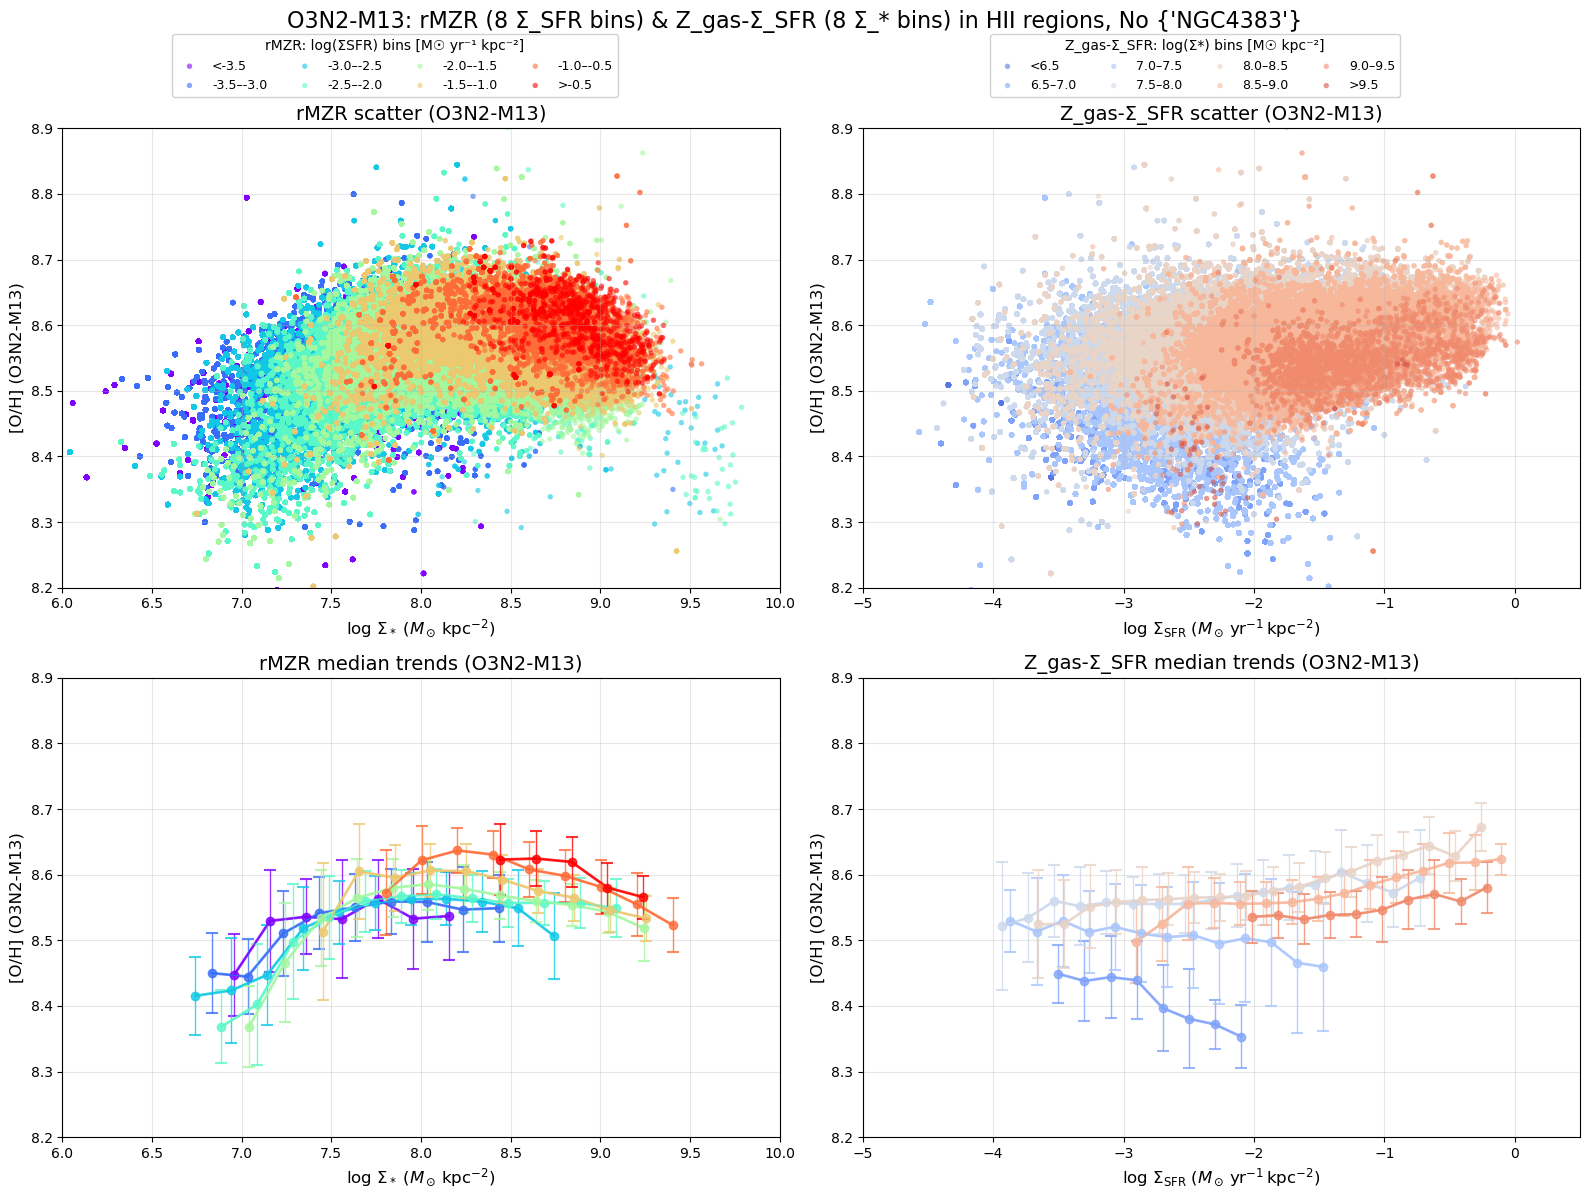


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [14]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_SFR bins for rMZR analysis
# Bins: <-3.5, [-3.5,-3.0), [-3.0,-2.5), [-2.5,-2.0), [-2.0,-1.5), [-1.5,-1.0), [-1.0,-0.5), >=-0.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)

# Define 8 bins with specific boundaries
n_bins = 8
# Bin edges: -inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, +inf
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]

print(f"\nΣ_SFR bins:")
print(f"  Number of bins: {n_bins}")

# Create bin labels
bin_labels = [
    '<-3.5',
    '-3.5–-3.0',
    '-3.0–-2.5',
    '-2.5–-2.0',
    '-2.0–-1.5',
    '-1.5–-1.0',
    '-1.0–-0.5',
    '>-0.5'
]

print(f"\n8 SFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 8 Σ_* bins for Z_gas-Σ_SFR analysis
# Bins: <6.5, [6.5,7.0), [7.0,7.5), [7.5,8.0), [8.0,8.5), [8.5,9.0), [9.0,9.5), >=9.5
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)

# Define 8 Σ_* bins with specific boundaries
n_bins_sigmaM = 8
# Bin edges: -inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, +inf
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]

print(f"\nΣ_* bins:")
print(f"  Number of bins: {n_bins_sigmaM}")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = [
    '<6.5',
    '6.5–7.0',
    '7.0–7.5',
    '7.5–8.0',
    '8.0–8.5',
    '8.5–9.0',
    '9.0–9.5',
    '>9.5'
]

print(f"\n8 Σ_* bins:")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 8 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes (swap top-right with bottom-left)
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 8 Σ_SFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")

legend_handles_sfr = []
legend_labels_sfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.set_title(f'rMZR scatter ({calib_name_HII})', fontsize=14)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.set_title(f'rMZR median trends ({calib_name_HII})', fontsize=14)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_SFR scatter (in 8 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing - handle all bins uniformly
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_SFR, y=[O/H])
        x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_SFR)
        sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(sfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_SFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_scatter.set_title(f'Z_gas-Σ_SFR scatter ({calib_name_HII})', fontsize=14)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-5.0, 0.5)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_SFR median trends
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_median.set_title(f'Z_gas-Σ_SFR median trends ({calib_name_HII})', fontsize=14)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-5.0, 0.5)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'{calib_name_HII}: rMZR (8 Σ_SFR bins) & Z_gas-Σ_SFR (8 Σ_* bins) in HII regions, No {excluded_galaxies}', 
             fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=4, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣSFR) bins [M☉ yr⁻¹ kpc⁻²]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=4, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_SFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
plt.savefig('Plot_20251117_MAUVE_Monthly_Meetiing/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
